# Ghana OSM Roads — Sentinel-2 Baseline Analysis (2017–2023)

Comprehensive pre-modelling data analysis. All figures are designed for direct
inclusion in the dissertation.

**Structure**
1. Setup & Data Loading
2. Baseline Spectral Characterisation
3. Seasonal Patterns
4. Year-on-Year Trends
5. Road-Level Temporal Features
6. Regional Analysis
7. Road Surface Analysis (OSM PBF — paved vs unpaved)


## Part 1 — Setup & Data Loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as sp_stats

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

def find_repo_root(start=None, repo_name="Sentinel-FYP"):
    start = (Path(start) if start else Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if p.name == repo_name:
            return p
    raise FileNotFoundError(f"Repo root {repo_name!r} not found from {start}")

ROOT       = find_repo_root()
DATA_DIR   = ROOT / "data"
PAR_ROOT   = DATA_DIR / "ghana_parquet"
REGION_CSV = DATA_DIR / "roads_region_lookup.csv"
PBF_PATH   = DATA_DIR / "ghana-260415.osm.pbf"

IDX_COLS    = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
LOAD_COLS   = ["osm_id", "fclass", "quarter"] + IDX_COLS
KEEP_CLASSES = ["residential", "service", "primary", "secondary",
                "tertiary", "trunk", "unclassified"]
CLASS_ORDER  = ["trunk", "primary", "secondary", "tertiary",
                "residential", "service", "unclassified"]
YEARS = list(range(2017, 2024))
QMAP  = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}
QLABELS = ["Q1\n(Jan–Mar)", "Q2\n(Apr–Jun)", "Q3\n(Jul–Sep)", "Q4\n(Oct–Dec)"]

PALETTE       = sns.color_palette("tab10", n_colors=len(CLASS_ORDER))
CLASS_PALETTE = dict(zip(CLASS_ORDER, PALETTE))

print("Repo root :", ROOT)
print("Parquet   :", PAR_ROOT, "— exists:", PAR_ROOT.exists())
print("PBF       :", PBF_PATH, "— exists:", PBF_PATH.exists())


Repo root : /Users/miranda/Documents/GitHub/Sentinel-FYP
Parquet   : /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana_parquet — exists: True
PBF       : /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260415.osm.pbf — exists: True


In [2]:
# Load all year partitions (2017–2023)
frames = []
for ydir in sorted(PAR_ROOT.glob("year=*")):
    year = int(ydir.name.split("=")[1])
    if year not in YEARS:
        continue
    pqs = sorted(ydir.glob("*.parquet"))
    if not pqs:
        print(f"  Warning: no parquet in {ydir.name}"); continue
    df_y = pd.read_parquet(pqs[0], columns=LOAD_COLS)
    df_y["year"] = year
    frames.append(df_y)
    print(f"  {ydir.name}: {len(df_y):,} rows")

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows loaded: {len(raw):,}")


  year=2017: 658,208 rows
  year=2018: 987,312 rows
  year=2019: 1,316,416 rows
  year=2020: 1,316,416 rows
  year=2021: 1,316,416 rows
  year=2022: 1,316,416 rows
  year=2023: 1,316,416 rows

Total rows loaded: 8,227,600


In [3]:
# Clean and standardise
raw["fclass"]  = raw["fclass"].astype(str).str.strip().str.lower()
raw["quarter"] = raw["quarter"].astype(str).str.strip().str.upper()
raw = raw[raw["fclass"].isin(KEEP_CLASSES)].copy()
raw["qnum"] = raw["quarter"].map(QMAP)
raw = raw.dropna(subset=["qnum"]).copy()
raw["qnum"] = raw["qnum"].astype(int)
for c in IDX_COLS:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

rows_before = len(raw)
raw = raw.dropna(subset=IDX_COLS)
in_range = np.logical_and.reduce([(raw[c] >= -1) & (raw[c] <= 1) for c in IDX_COLS])
raw = raw[in_range].copy()
zero_mask = (raw[IDX_COLS] == 0).any(axis=1)
raw = raw[~zero_mask].copy()
rows_after = len(raw)

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows after  cleaning : {rows_after:,}  ({100*(rows_before-rows_after)/rows_before:.1f}% removed)")
print("Years    :", sorted(raw["year"].unique()))
print("Classes  :", sorted(raw["fclass"].unique()))

raw["osm_id"] = raw["osm_id"].astype(str)
df = raw.copy(); del raw


Rows before cleaning : 8,227,600
Rows after  cleaning : 6,375,404  (22.5% removed)
Years    : [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Classes  : ['primary', 'residential', 'secondary', 'service', 'tertiary', 'trunk', 'unclassified']


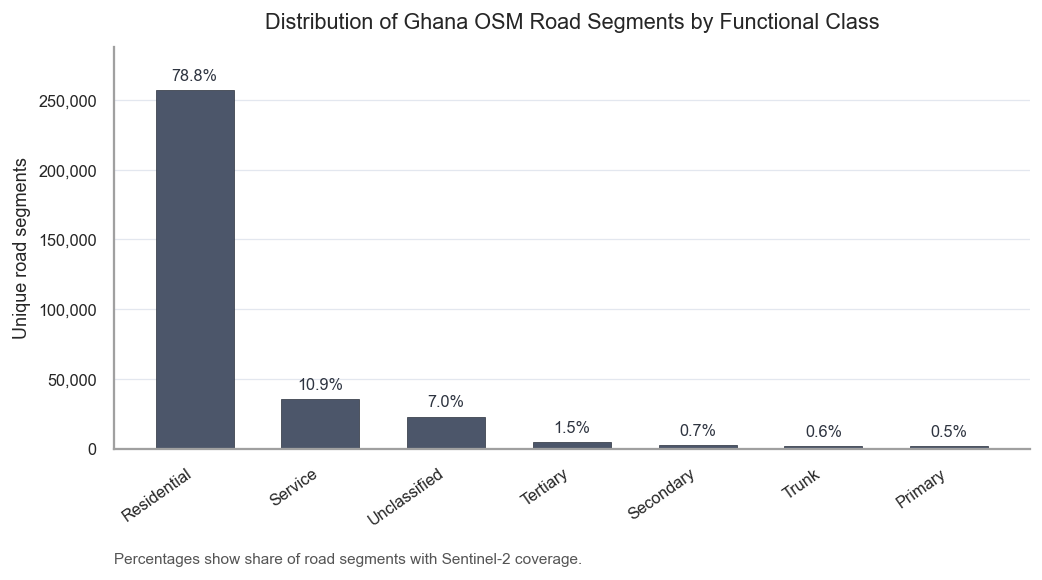

fclass
residential     257398
service          35627
unclassified     22950
tertiary          4755
secondary         2397
trunk             1822
primary           1597


In [68]:
# ── Figure 1: Road class distribution ───────────────────────────────────────
road_counts = (
    df.groupby("fclass")["osm_id"].nunique()
    .reindex(CLASS_ORDER)
    .rename("unique_roads")
)

plot_counts = road_counts.sort_values(ascending=False)
plot_share = 100 * plot_counts / plot_counts.sum()

fig, ax = plt.subplots(figsize=(8.2, 4.8))

bar_color = "#4C566A"
edge_color = "#2E3440"

x = np.arange(len(plot_counts))

bars = ax.bar(
    x,
    plot_counts.values,
    color=bar_color,
    edgecolor=edge_color,
    linewidth=0.4,
    width=0.62,
)

for bar, count, share in zip(bars, plot_counts.values, plot_share.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + plot_counts.max() * 0.018,
        f"{share:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2E3440",
    )

ax.set_xticks(x)
ax.set_xticklabels(
    [c.capitalize() for c in plot_counts.index],
    rotation=35,
    ha="right",
)

ax.set_ylabel("Unique road segments")
ax.set_xlabel("")
ax.set_title(
    "Distribution of Ghana OSM Road Segments by Functional Class",
    fontsize=12,
    pad=10,
)

ax.set_ylim(0, plot_counts.max() * 1.12)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

ax.grid(axis="y", color="#D8DEE9", linewidth=0.7, alpha=0.7)
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#A0A0A0")
ax.spines["bottom"].set_color("#A0A0A0")

caption_text = "Percentages show share of road segments with Sentinel-2 coverage."
ax.text(
    0,
    -0.26,
    caption_text,
    transform=ax.transAxes,
    fontsize=8.5,
    color="#555555",
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

print(plot_counts.to_string())

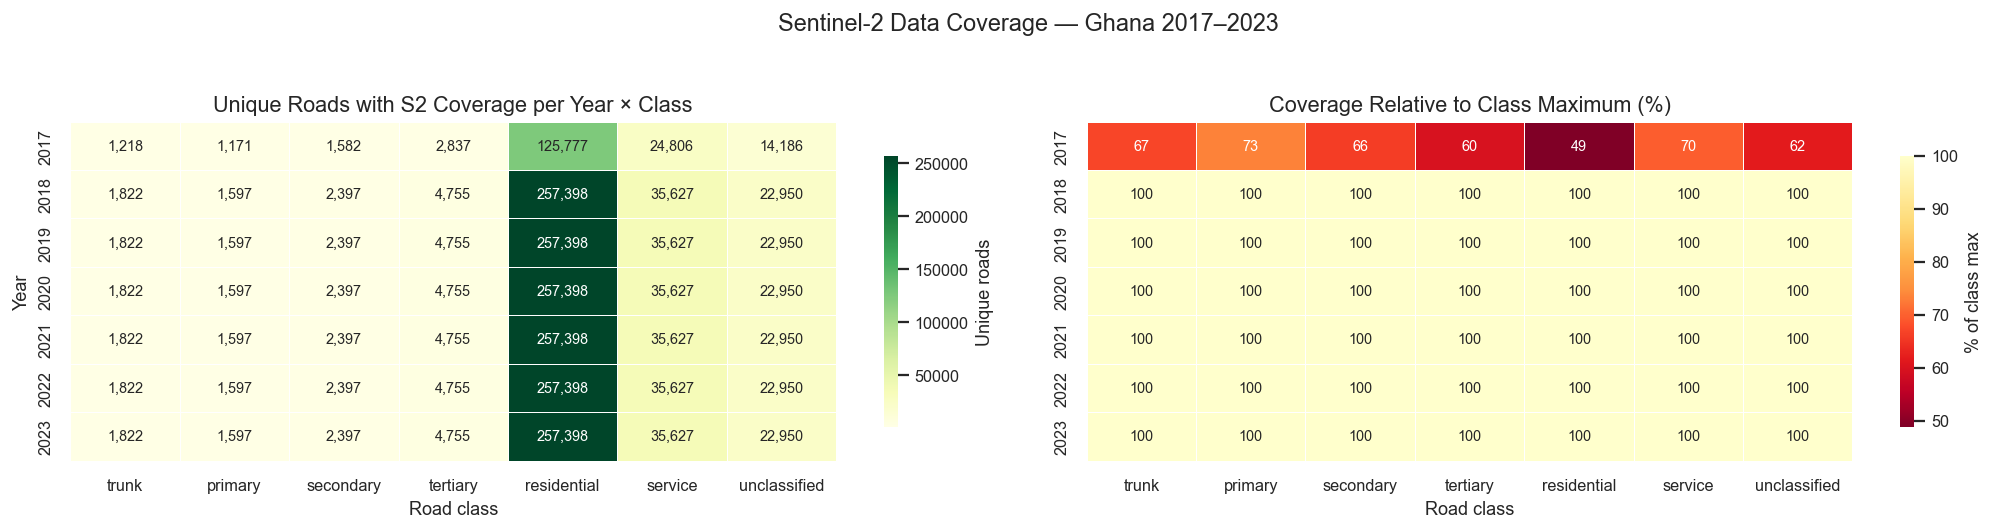

In [5]:
# ── Figure 2: Data coverage heatmap — unique roads per year × class ──────────
coverage = (
    df.groupby(["year", "fclass"])["osm_id"].nunique()
    .unstack("fclass").reindex(columns=CLASS_ORDER)
)
coverage_pct = 100 * coverage.div(coverage.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(coverage, annot=True, fmt=",", cmap="YlGn", linewidths=0.4, ax=axes[0],
            cbar_kws={"label": "Unique roads", "shrink": 0.8}, annot_kws={"size": 8})
axes[0].set_title("Unique Roads with S2 Coverage per Year × Class")
axes[0].set_xlabel("Road class"); axes[0].set_ylabel("Year")

sns.heatmap(coverage_pct, annot=True, fmt=".0f", cmap="YlOrRd_r", linewidths=0.4, ax=axes[1],
            cbar_kws={"label": "% of class max", "shrink": 0.8}, annot_kws={"size": 8})
axes[1].set_title("Coverage Relative to Class Maximum (%)")
axes[1].set_xlabel("Road class"); axes[1].set_ylabel("")

plt.suptitle("Sentinel-2 Data Coverage — Ghana 2017–2023", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## Part 2 — Baseline Spectral Characterisation

Summary statistics and distributions of the five Sentinel-2 indices across the
seven OSM road classes, pooled across all years 2017–2023.

| Index | Formula | Interpretation |
|-------|---------|----------------|
| NDVI  | (B8−B4)/(B8+B4) | Vegetation greenness — high = vegetated surroundings |
| NDMI  | (B8−B11)/(B8+B11) | Canopy moisture — high = wet vegetation |
| NDBI  | (B11−B8)/(B11+B8) | Built-up / impervious — high = urban |
| NDWI  | (B3−B8)/(B3+B8) | Open water — near mirror of NDBI (same bands, inverted) |
| BSI   | ((B11+B4)−(B8+B2))/((B11+B4)+(B8+B2)) | Bare soil — high = exposed/degraded surface |


In [6]:
# Compact mean ± std + median (IQR) table
def iqr_fn(x): return x.quantile(0.75) - x.quantile(0.25)

rows = []
for cls in CLASS_ORDER:
    sub = df[df["fclass"] == cls]
    row = {"road_class": cls}
    for c in IDX_COLS:
        m, s = sub[c].mean(), sub[c].std()
        med, iq = sub[c].median(), iqr_fn(sub[c])
        row[f"{c}"] = f"{m:.3f} ± {s:.3f}  [{med:.3f} ({iq:.3f})]"
    rows.append(row)

stats_tbl = pd.DataFrame(rows).set_index("road_class")
print("Mean ± Std  [Median (IQR)] — 2017–2023 pooled")
display(stats_tbl)


Mean ± Std  [Median (IQR)] — 2017–2023 pooled


,NDVI,NDMI,NDBI,NDWI,BSI
road_class,,,,,
trunk,0.191 ± 0.131 [0.162 (0.179)],-0.074 ± 0.090 [-0.095 (0.122)],0.074 ± 0.090 [0.095 (0.122)],-0.256 ± 0.124 [-0.252 (0.178)],0.106 ± 0.086 [0.122 (0.114)]
primary,0.191 ± 0.143 [0.155 (0.192)],-0.080 ± 0.093 [-0.101 (0.121)],0.080 ± 0.093 [0.101 (0.121)],-0.258 ± 0.141 [-0.241 (0.217)],0.111 ± 0.089 [0.126 (0.110)]
secondary,0.197 ± 0.147 [0.153 (0.205)],-0.077 ± 0.096 [-0.102 (0.133)],0.077 ± 0.096 [0.102 (0.133)],-0.262 ± 0.140 [-0.243 (0.209)],0.107 ± 0.090 [0.125 (0.121)]
tertiary,0.226 ± 0.161 [0.179 (0.235)],-0.072 ± 0.104 [-0.102 (0.151)],0.072 ± 0.104 [0.102 (0.151)],-0.295 ± 0.149 [-0.284 (0.227)],0.106 ± 0.098 [0.130 (0.139)]
residential,0.255 ± 0.138 [0.234 (0.181)],-0.081 ± 0.089 [-0.097 (0.123)],0.081 ± 0.089 [0.097 (0.123)],-0.326 ± 0.124 [-0.331 (0.152)],0.116 ± 0.087 [0.132 (0.121)]
service,0.181 ± 0.133 [0.149 (0.160)],-0.094 ± 0.082 [-0.110 (0.103)],0.094 ± 0.082 [0.110 (0.103)],-0.250 ± 0.132 [-0.240 (0.172)],0.120 ± 0.080 [0.136 (0.100)]
unclassified,0.361 ± 0.179 [0.344 (0.287)],-0.027 ± 0.128 [-0.043 (0.221)],0.027 ± 0.128 [0.043 (0.221)],-0.412 ± 0.138 [-0.419 (0.177)],0.070 ± 0.125 [0.084 (0.215)]


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/3912844913.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/3912844913.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=10)
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/3912844913.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/3912844913.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of

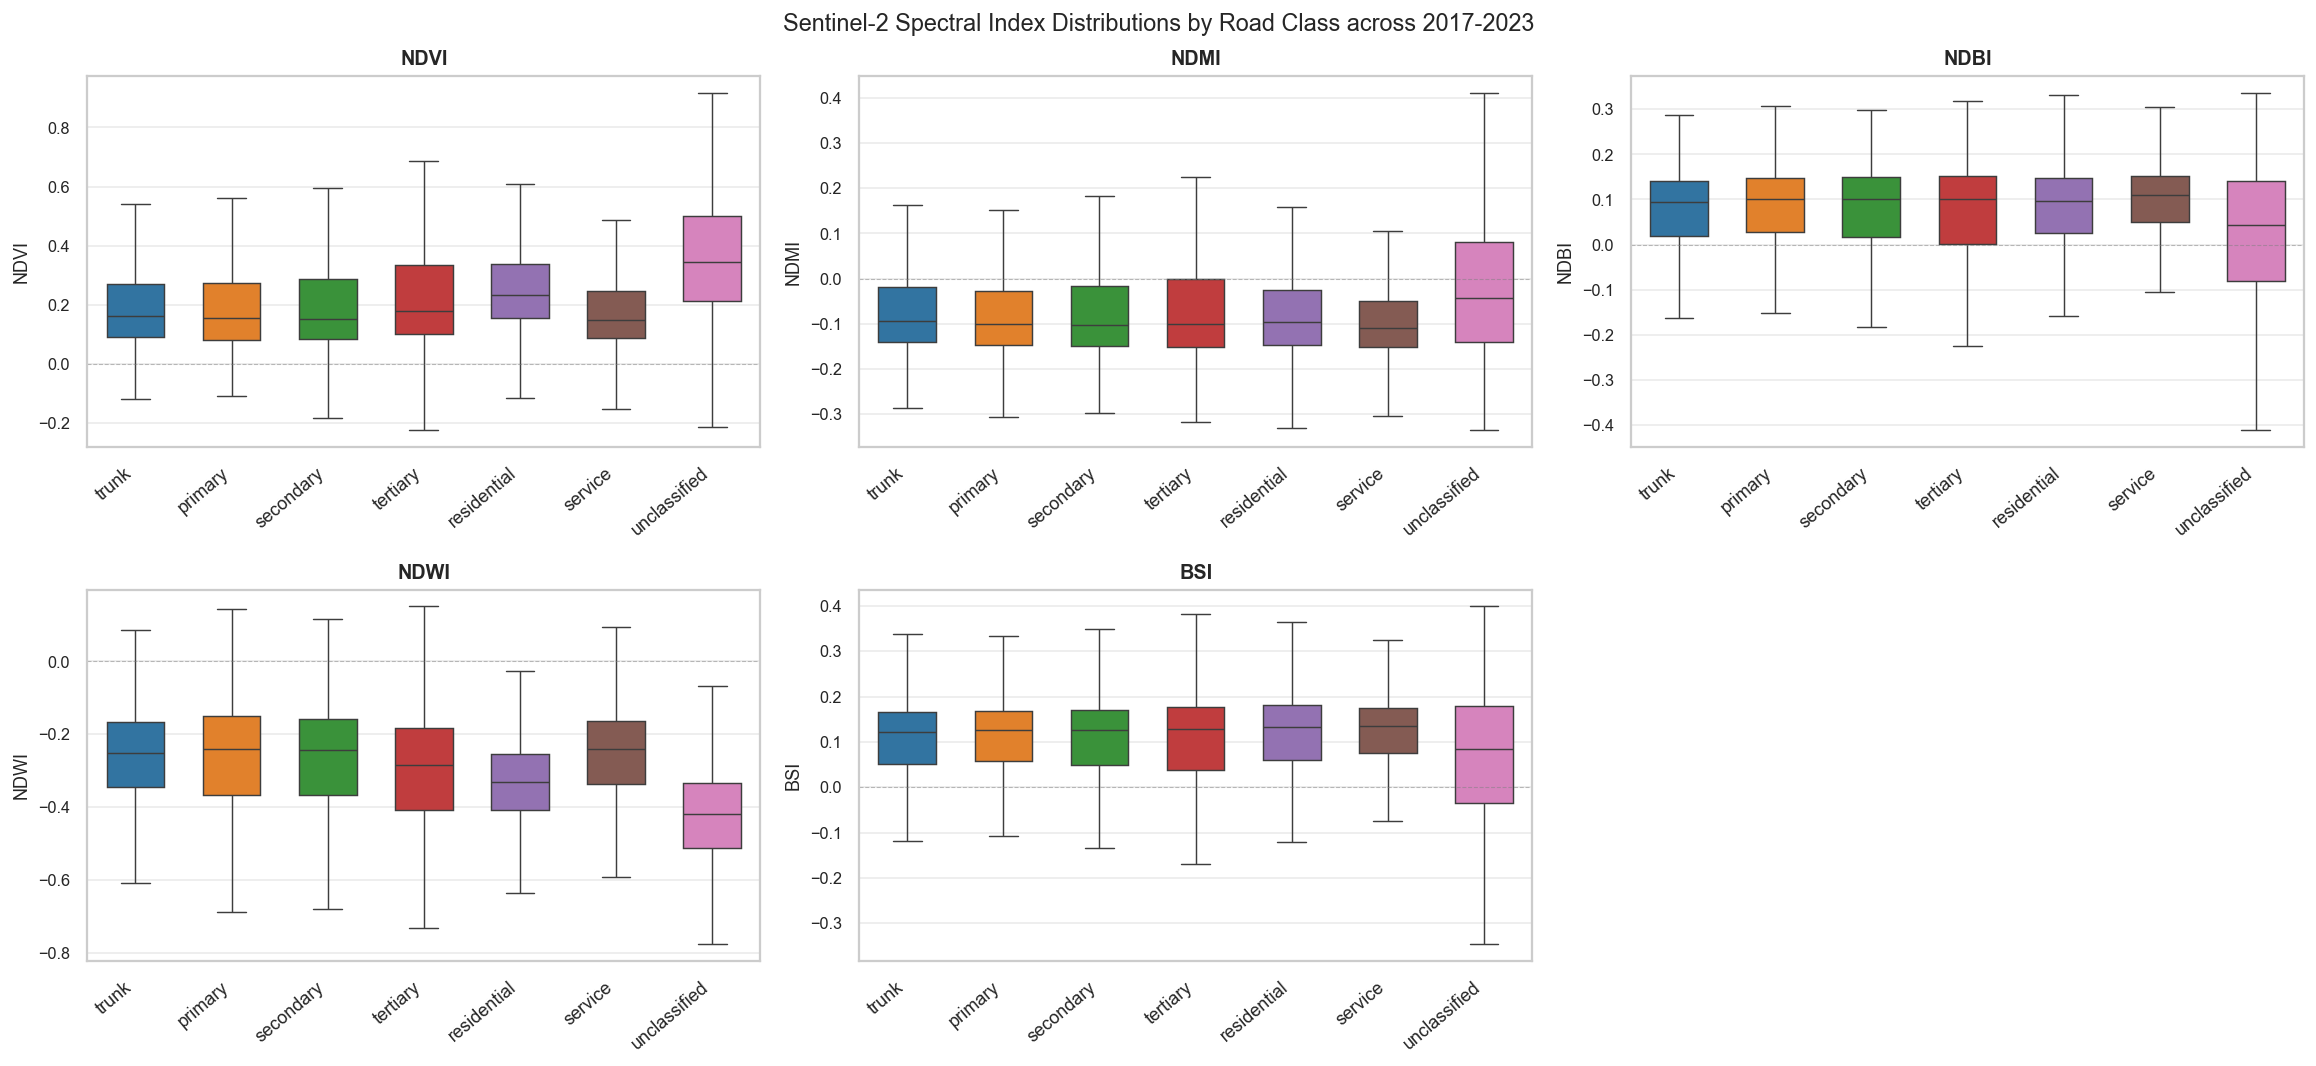

In [66]:
# ── Figure 3: Spectral index distributions — 2-row boxplots ───────────────────
plot_df = df.copy()
plot_df["fclass"] = pd.Categorical(
    plot_df["fclass"],
    categories=CLASS_ORDER,
    ordered=True,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False)
axes = axes.flatten()

for i, idx in enumerate(IDX_COLS):
    ax = axes[i]

    sns.boxplot(
        data=plot_df,
        x="fclass",
        y=idx,
        order=CLASS_ORDER,
        showfliers=False,
        palette=CLASS_PALETTE,
        ax=ax,
        linewidth=0.8,
        width=0.6,
    )

    ax.set_xlabel("")
    ax.set_ylabel(idx, fontsize=10)
    ax.set_title(idx, fontsize=11, fontweight="bold")
    ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=10)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.35)

axes[-1].axis("off")

fig.suptitle(
    "Sentinel-2 Spectral Index Distributions by Road Class across 2017-2023",
    fontsize=13,
    y=0.91,
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


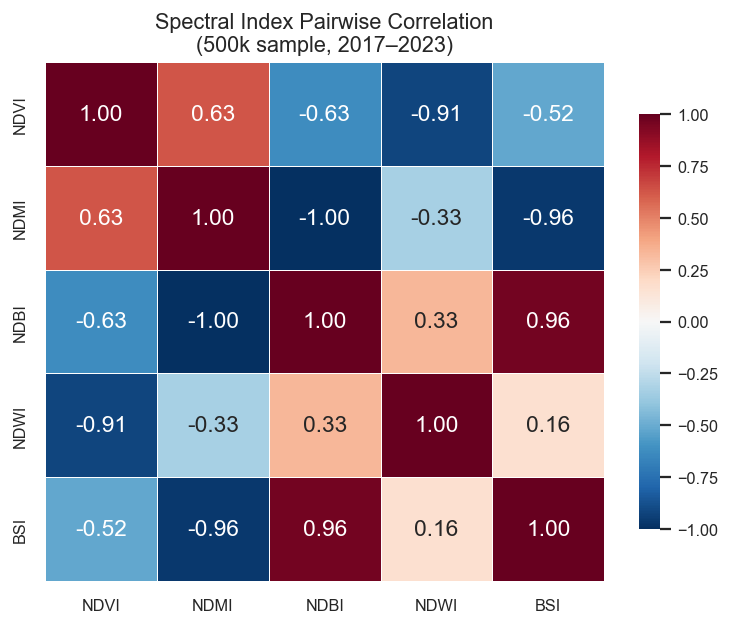


NDBI = −NDWI by construction (same bands, inverted sign).
In modelling use only one of the two to avoid perfect multicollinearity.


In [8]:
# ── Figure 4: Spectral index correlation heatmap ─────────────────────────────
sample = df[IDX_COLS].sample(min(500_000, len(df)), random_state=42)
corr   = sample.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Spectral Index Pairwise Correlation\n(500k sample, 2017–2023)")
plt.tight_layout(); plt.show()
print("\nNDBI = −NDWI by construction (same bands, inverted sign).")
print("In modelling use only one of the two to avoid perfect multicollinearity.")


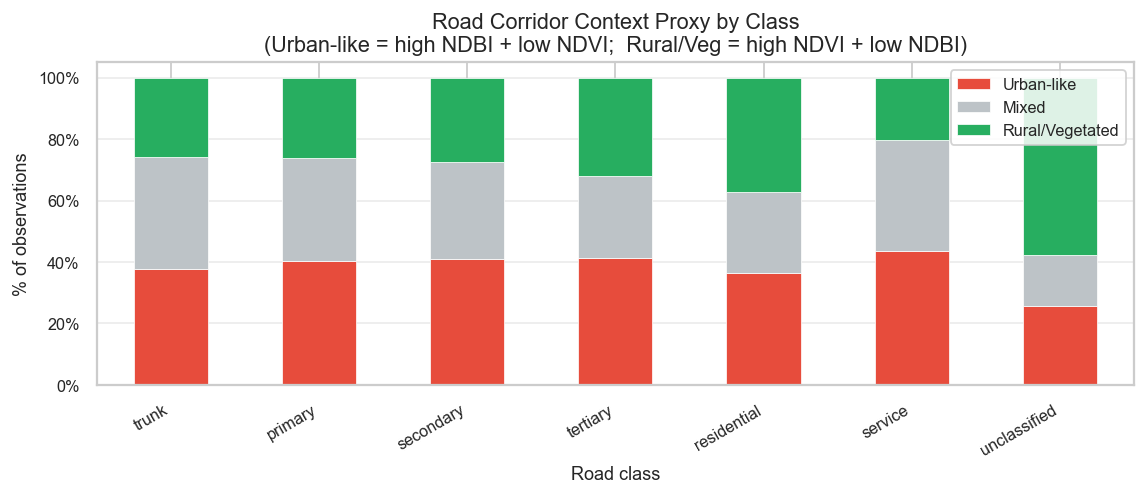

In [9]:
# ── Figure 5: Road corridor context proxy (Urban / Mixed / Rural) ─────────────
ndbi_thr = df["NDBI"].quantile(0.60)
ndvi_thr = df["NDVI"].quantile(0.60)

def ctx(row):
    if row["NDBI"] >= ndbi_thr and row["NDVI"] < ndvi_thr:   return "Urban-like"
    elif row["NDVI"] >= ndvi_thr and row["NDBI"] < ndbi_thr: return "Rural/Vegetated"
    return "Mixed"

s = df[["fclass", "NDVI", "NDBI"]].sample(500_000, random_state=0)
s["context"] = s.apply(ctx, axis=1)

proxy_pct = (
    s.groupby(["fclass", "context"]).size().reset_index(name="n")
    .pivot(index="fclass", columns="context", values="n")
    .reindex(CLASS_ORDER).fillna(0)
)
proxy_pct = proxy_pct.div(proxy_pct.sum(axis=1), axis=0) * 100
for col in ["Urban-like", "Mixed", "Rural/Vegetated"]:
    if col not in proxy_pct.columns:
        proxy_pct[col] = 0
proxy_pct = proxy_pct[["Urban-like", "Mixed", "Rural/Vegetated"]]

fig, ax = plt.subplots(figsize=(9, 4))
proxy_pct.plot(kind="bar", stacked=True, ax=ax,
               color=["#e74c3c", "#bdc3c7", "#27ae60"], edgecolor="white", linewidth=0.4)
ax.set_xlabel("Road class"); ax.set_ylabel("% of observations")
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_title("Road Corridor Context Proxy by Class\n"
             "(Urban-like = high NDBI + low NDVI;  Rural/Veg = high NDVI + low NDBI)")
ax.legend(loc="upper right", framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", alpha=0.35)
plt.tight_layout(); plt.show()


## Part 3 — Seasonal Patterns

Ghana has a bimodal rainfall regime: main wet season March–July, secondary wet
season September–November, with dry harmattan conditions in Q1 (Dec–Mar).
NDVI peaks Q2–Q3 as vegetation greens up; BSI peaks Q1 as bare soil is exposed.


In [10]:
# Quarterly means per class, pooled across all years
q_mean = (
    df.groupby(["fclass", "qnum"])[IDX_COLS].mean().reset_index()
)
q_mean["fclass"] = pd.Categorical(q_mean["fclass"], categories=CLASS_ORDER, ordered=True)
q_mean = q_mean.sort_values(["fclass", "qnum"])


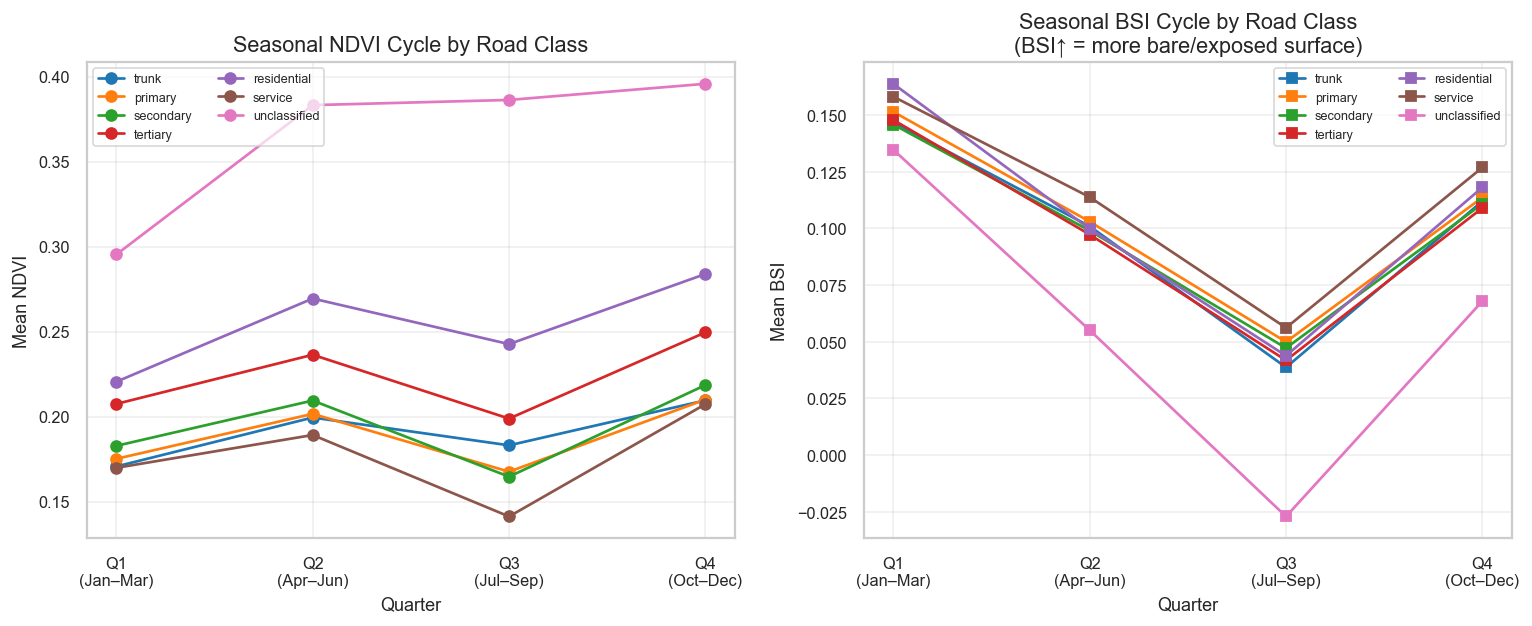

In [50]:
# ── Figure 6: NDVI and BSI seasonal cycles (side-by-side) ────────────────────
fig, axes = plt.subplots(1,2, figsize=(12, 5))

for cls in CLASS_ORDER:
    sub = q_mean[q_mean["fclass"] == cls]
    col = CLASS_PALETTE[cls]
    axes[0].plot(sub["qnum"], sub["NDVI"], marker="o", label=cls, color=col, linewidth=1.5)
    axes[1].plot(sub["qnum"], sub["BSI"],  marker="s", label=cls, color=col, linewidth=1.5)

for ax, ylabel, title in [
    (axes[0], "Mean NDVI", "Seasonal NDVI Cycle by Road Class"),
    (axes[1], "Mean BSI",  "Seasonal BSI Cycle by Road Class\n(BSI↑ = more bare/exposed surface)"),
]:
    ax.set_xticks([1, 2, 3, 4]); ax.set_xticklabels(QLABELS)
    ax.set_xlabel("Quarter"); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(ncol=2, framealpha=0.7, fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/1609526384.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_mean.groupby("fclass")[["NDVI", "BSI"]]


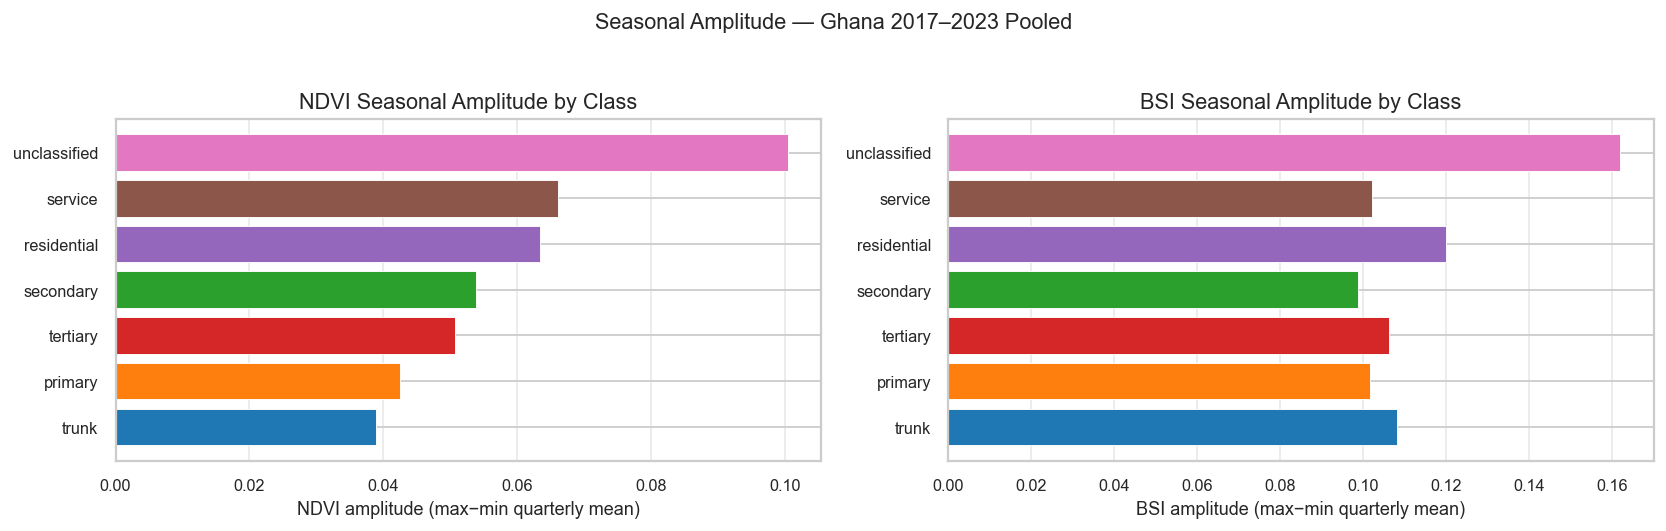

In [12]:
# ── Figure 7: Seasonal amplitude by class ────────────────────────────────────
amp = (
    q_mean.groupby("fclass")[["NDVI", "BSI"]]
    .agg(lambda x: x.max() - x.min())
    .reindex(CLASS_ORDER).reset_index()
)
amp.columns = ["fclass", "ndvi_amp", "bsi_amp"]
amp = amp.sort_values("ndvi_amp", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, xlabel, title in [
    (axes[0], "ndvi_amp", "NDVI amplitude (max−min quarterly mean)",
     "NDVI Seasonal Amplitude by Class"),
    (axes[1], "bsi_amp",  "BSI amplitude (max−min quarterly mean)",
     "BSI Seasonal Amplitude by Class"),
]:
    colors = [CLASS_PALETTE[c] for c in amp["fclass"]]
    ax.barh(amp["fclass"], amp[col], color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel(xlabel); ax.set_title(title); ax.grid(axis="x", alpha=0.4)

plt.suptitle("Seasonal Amplitude — Ghana 2017–2023 Pooled", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## Part 4 — Year-on-Year Trends (2017–2023)

Annual mean spectral values per road class track long-run changes in road-corridor
land cover. Year-on-year deltas highlight anomalous years (rainfall anomalies,
cloud compositing artefacts).


In [13]:
# Annual means per class + YoY deltas for all indices
yearly = (
    df.groupby(["fclass", "year"])[IDX_COLS].mean()
    .reset_index().sort_values(["fclass", "year"])
)
for c in IDX_COLS:
    yearly[f"{c}_yoy"] = yearly.groupby("fclass")[c].diff()
yearly["fclass"] = pd.Categorical(yearly["fclass"], categories=CLASS_ORDER, ordered=True)


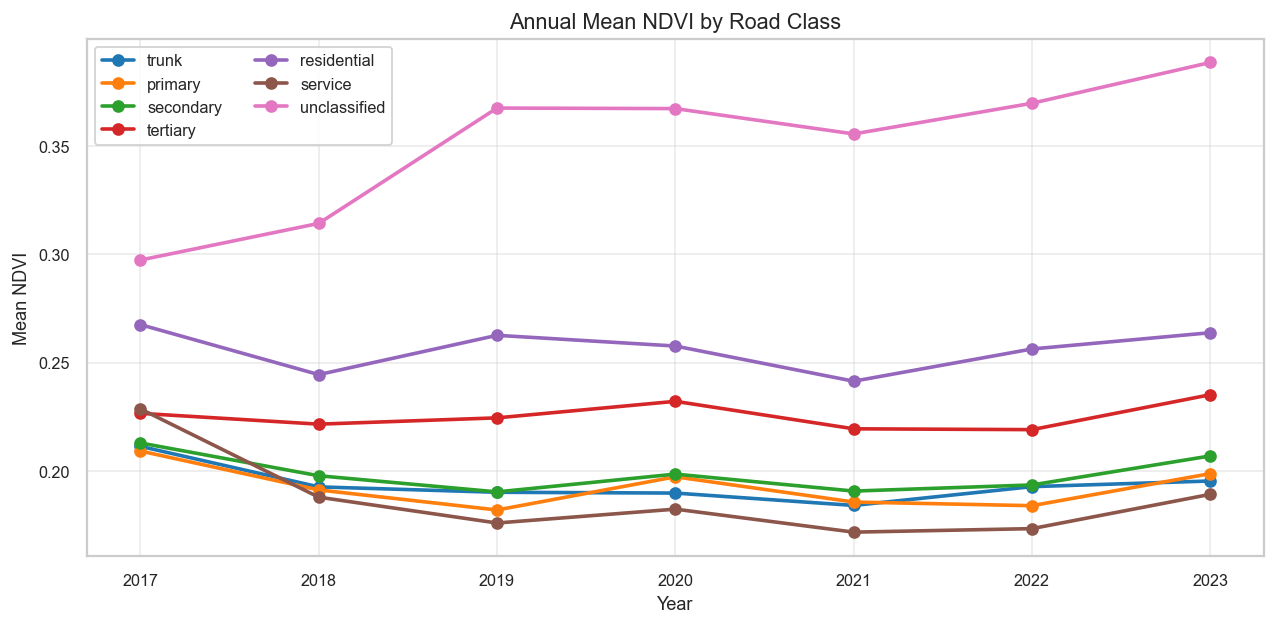

In [61]:
# ── Figure 8: Annual NDVI trend lines 2017–2023 ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for cls in CLASS_ORDER:
    sub = yearly[yearly["fclass"] == cls].sort_values("year")
    ax.plot(sub["year"], sub["NDVI"], marker="o", label=cls,
            color=CLASS_PALETTE[cls], linewidth=2)
ax.set_xticks(YEARS); ax.set_xlabel("Year"); ax.set_ylabel("Mean NDVI")
ax.set_title("Annual Mean NDVI by Road Class")
ax.legend(ncol=2, framealpha=0.85); ax.grid(alpha=0.35)
plt.tight_layout(); plt.show()


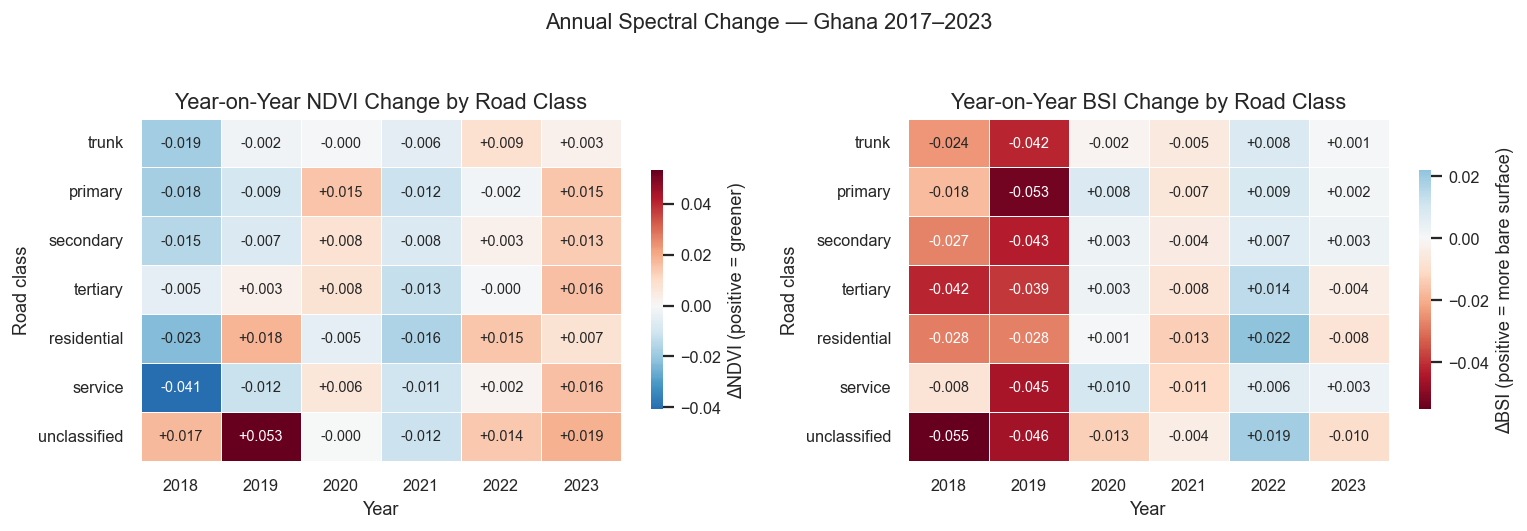

In [53]:
# ── Figure 9: YoY NDVI and BSI delta heatmaps ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
yoy_ndvi = (yearly.dropna(subset=["NDVI_yoy"])
            .pivot(index="fclass", columns="year", values="NDVI_yoy")
            .reindex(CLASS_ORDER))
yoy_bsi  = (yearly.dropna(subset=["BSI_yoy"])
            .pivot(index="fclass", columns="year", values="BSI_yoy")
            .reindex(CLASS_ORDER))

for ax, pivot, label, cmap in [
    (axes[0], yoy_ndvi, "ΔNDVI (positive = greener)", "RdBu_r"),
    (axes[1], yoy_bsi,  "ΔBSI (positive = more bare surface)", "RdBu"),
]:
    sns.heatmap(pivot, annot=True, fmt="+.3f", cmap=cmap, center=0, linewidths=0.5, ax=ax,
                cbar_kws={"label": label, "shrink": 0.7}, annot_kws={"size": 8})
    ax.set_xlabel("Year"); ax.set_ylabel("Road class")

axes[0].set_title("Year-on-Year NDVI Change by Road Class")
axes[1].set_title("Year-on-Year BSI Change by Road Class")
plt.suptitle("Annual Spectral Change — Ghana 2017–2023", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## Part 5 — Road-Level Temporal Features

Per-road OLS linear trend slopes capture cumulative spectral change at segment
level across 2017–2023. A negative NDVI slope combined with a positive BSI slope
is used as a proxy for potential surface degradation.

> **Limitation**: slopes reflect road-corridor conditions (not pure pavement
> signals) and are sensitive to seasonal variability, cloud cover, and land-use
> change around roads. Treat as exploratory signals, not validated condition labels.


In [16]:
# Vectorised OLS slope computation
# t = year*4 + qnum  (quarterly time index across 2017–2023)
sub = df[["osm_id", "fclass", "year", "qnum", "NDVI", "BSI"]].dropna().copy()
sub["t"]      = sub["year"] * 4 + sub["qnum"]
sub["t_ndvi"] = sub["t"] * sub["NDVI"]
sub["t_bsi"]  = sub["t"] * sub["BSI"]
sub["t2"]     = sub["t"] ** 2

print("Computing per-road OLS aggregates …")
agg = sub.groupby("osm_id").agg(
    fclass=("fclass","first"), n=("t","count"),
    sum_t=("t","sum"), sum_t2=("t2","sum"),
    sum_ndvi=("NDVI","sum"), sum_bsi=("BSI","sum"),
    sum_t_n=("t_ndvi","sum"), sum_t_b=("t_bsi","sum"),
).reset_index()

denom = agg["n"] * agg["sum_t2"] - agg["sum_t"] ** 2
valid = (agg["n"] >= 6) & (denom.abs() > 1e-10)
road_slopes = agg[valid].copy()
road_slopes["ndvi_slope"] = (
    road_slopes["n"] * road_slopes["sum_t_n"] -
    road_slopes["sum_t"] * road_slopes["sum_ndvi"]) / denom[valid].values
road_slopes["bsi_slope"]  = (
    road_slopes["n"] * road_slopes["sum_t_b"] -
    road_slopes["sum_t"] * road_slopes["sum_bsi"])  / denom[valid].values
road_slopes["fclass"] = pd.Categorical(
    road_slopes["fclass"], categories=CLASS_ORDER, ordered=True)

print(f"Roads with valid slopes (≥6 obs): {len(road_slopes):,}")
road_slopes[["ndvi_slope", "bsi_slope"]].describe().round(6)


Computing per-road OLS aggregates …
Roads with valid slopes (≥6 obs): 326,546


,ndvi_slope,bsi_slope
count,326546.0000,326546.0000
mean,0.0007,-0.0010
std,0.0035,0.0027
min,-0.0335,-0.0174
25%,-0.0015,-0.0028
50%,0.0004,-0.0013
75%,0.0028,0.0004
max,0.0244,0.0230


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/389592721.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_rs, x="fclass", y=col, order=CLASS_ORDER,
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/389592721.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=35, ha="right"); ax.grid(axis="y", alpha=0.35)
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/389592721.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_rs, x="fclass", y=col, order=CLASS_ORDER,
/var/folders/vs/7b7k7q7s1v19prbw

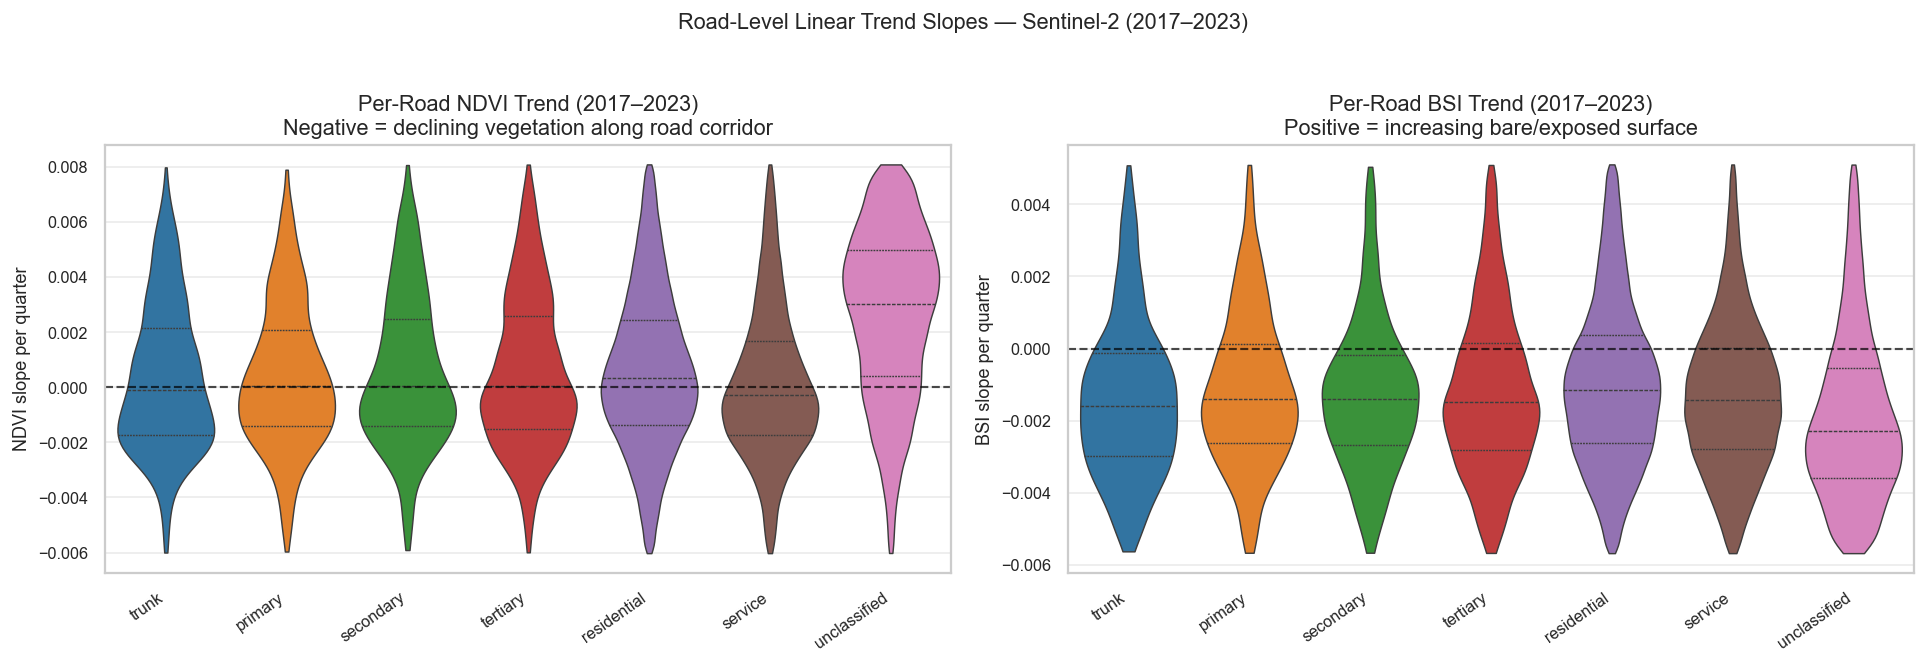

In [17]:
# ── Figure 10: NDVI and BSI slope distributions (violin) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, label, subtitle in [
    (axes[0], "ndvi_slope", "NDVI slope per quarter",
     "Negative = declining vegetation along road corridor"),
    (axes[1], "bsi_slope",  "BSI slope per quarter",
     "Positive = increasing bare/exposed surface"),
]:
    lo, hi = road_slopes[col].quantile([0.025, 0.975])
    plot_rs = road_slopes[(road_slopes[col] >= lo) & (road_slopes[col] <= hi)]
    sns.violinplot(data=plot_rs, x="fclass", y=col, order=CLASS_ORDER,
                   palette=CLASS_PALETTE, inner="quartile", ax=ax, linewidth=0.8, cut=0)
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.7)
    ax.set_xlabel(""); ax.set_ylabel(label)
    ax.set_title(f"Per-Road {label.split(' ')[0]} Trend (2017–2023)\n{subtitle}")
    ax.set_xticklabels(CLASS_ORDER, rotation=35, ha="right"); ax.grid(axis="y", alpha=0.35)

plt.suptitle("Road-Level Linear Trend Slopes — Sentinel-2 (2017–2023)", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


Temporal degradation signal (NDVI↓ AND BSI↑, 2017–2023):


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/2253884887.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = (road_slopes.groupby("fclass")


,total_roads,flagged,deg_pct
road_class,,,
trunk,1822,266,14.6000
primary,1597,279,17.5000
secondary,2397,334,13.9000
tertiary,4755,749,15.8000
residential,257398,46881,18.2000
service,35627,5225,14.7000
unclassified,22950,2151,9.4000


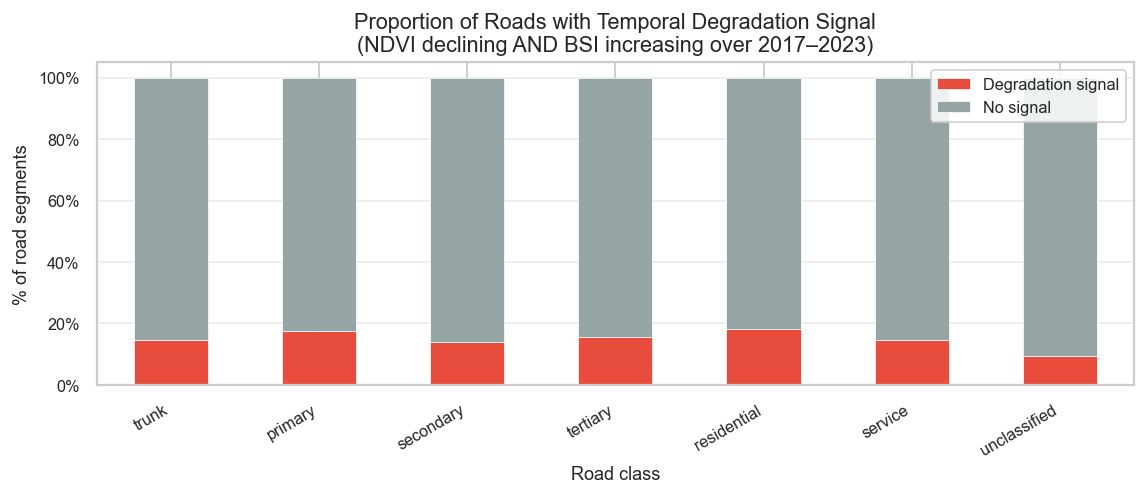

In [18]:
# Degradation flag: NDVI slope < 0 AND BSI slope > 0
road_slopes["deg_flag"] = (
    (road_slopes["ndvi_slope"] < 0) & (road_slopes["bsi_slope"] > 0)).astype(int)

risk = (road_slopes.groupby("fclass")
        .agg(total_roads=("osm_id","count"), flagged=("deg_flag","sum"))
        .reindex(CLASS_ORDER))
risk["deg_pct"] = 100 * risk["flagged"] / risk["total_roads"]
risk.index.name = "road_class"
print("Temporal degradation signal (NDVI↓ AND BSI↑, 2017–2023):")
display(risk.round(1))

# ── Figure 11: Degradation risk stacked bar ───────────────────────────────────
pct = pd.DataFrame({"Degradation signal": risk["deg_pct"],
                    "No signal": 100 - risk["deg_pct"]}, index=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(9, 4))
pct.plot(kind="bar", stacked=True, ax=ax,
         color=["#e74c3c", "#95a5a6"], edgecolor="white", linewidth=0.4)
ax.set_xlabel("Road class"); ax.set_ylabel("% of road segments")
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_title("Proportion of Roads with Temporal Degradation Signal\n"
             "(NDVI declining AND BSI increasing over 2017–2023)")
ax.legend(loc="upper right", framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.PercentFormatter()); ax.grid(axis="y", alpha=0.35)
plt.tight_layout(); plt.show()


## Part 6 — Regional Analysis

Roads are mapped to Ghana administrative regions via `data/roads_region_lookup.csv`
(produced by `get_roads_region.py` using a GEE spatial join). Regional variation
in road composition and spectral signals reflects agro-ecological and urban
differences across the country.


In [19]:
# Load region lookup + merge
lookup = pd.read_csv(REGION_CSV)
lookup["osm_id"] = lookup["osm_id"].astype(str)

df_reg = df.merge(
    lookup[["osm_id", "region"]].drop_duplicates("osm_id"),
    on="osm_id", how="left",
)
match_pct = 100 * df_reg["region"].notna().mean()
print(f"Region match: {match_pct:.1f}% of observations")
print(f"Regions: {sorted(df_reg['region'].dropna().unique())}")


Region match: 99.4% of observations
Regions: ['Ahafo', 'Ashanti', 'Bono', 'Bono East', 'Central', 'Eastern', 'Greater Accra', 'Northern', 'Northern East', 'Oti', 'Savannah', 'Upper East', 'Upper West', 'Volta', 'Western', 'Western North']


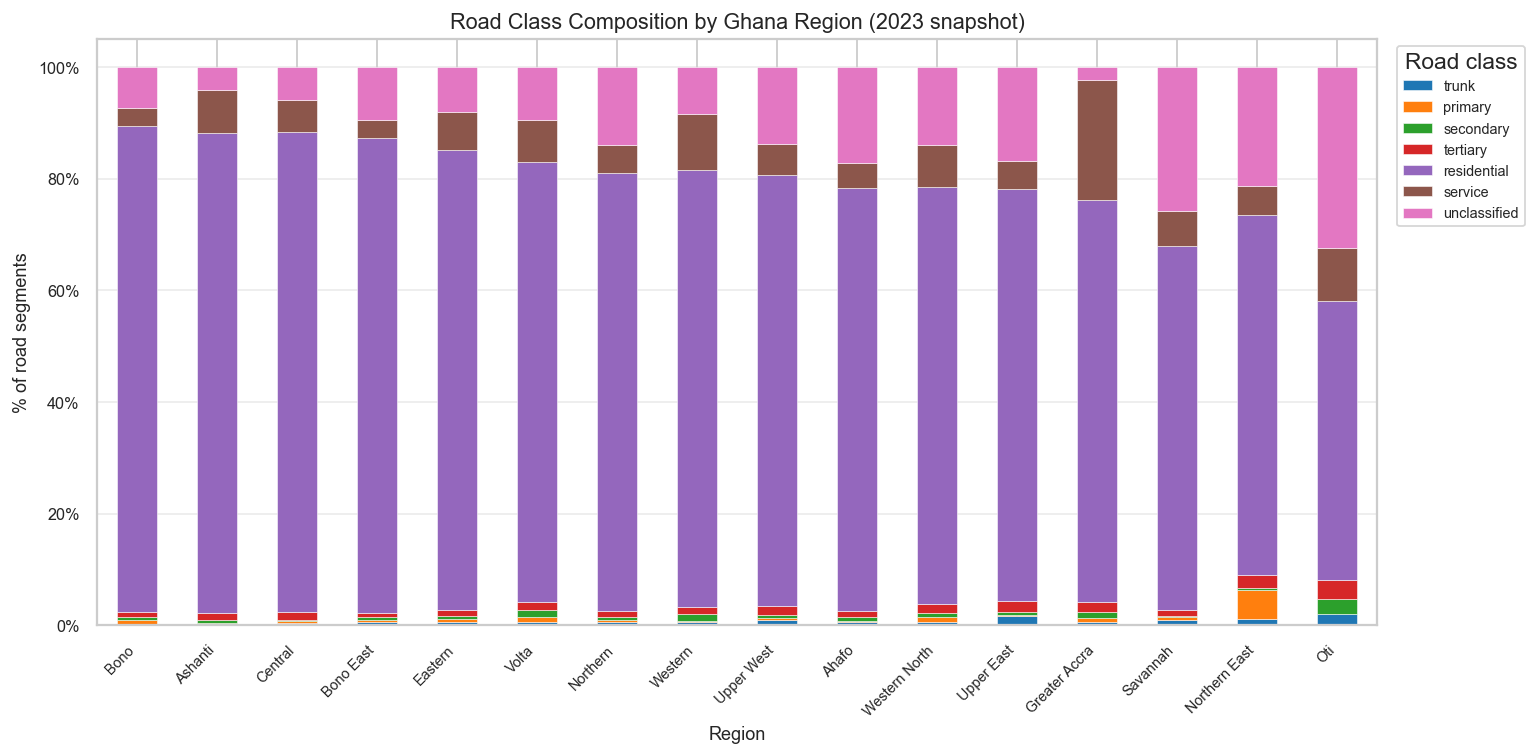

In [20]:
# ── Figure 12: Road class composition by region ──────────────────────────────
region_cls = (
    df_reg[df_reg["year"] == 2023].dropna(subset=["region"])
    .groupby(["region", "fclass"])["osm_id"].nunique()
    .reset_index(name="road_count")
)
pivot_rc = (region_cls.pivot(index="region", columns="fclass", values="road_count")
            .reindex(columns=CLASS_ORDER).fillna(0))
pivot_rc_pct = pivot_rc.div(pivot_rc.sum(axis=1), axis=0) * 100
pivot_rc_pct = pivot_rc_pct.sort_values("residential", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_rc_pct.plot(kind="bar", stacked=True, ax=ax,
                  color=[CLASS_PALETTE[c] for c in CLASS_ORDER],
                  edgecolor="white", linewidth=0.3)
ax.set_xlabel("Region"); ax.set_ylabel("% of road segments")
ax.set_xticklabels(pivot_rc_pct.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Road Class Composition by Ghana Region (2023 snapshot)")
ax.legend(title="Road class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter()); ax.grid(axis="y", alpha=0.35)
plt.tight_layout(); plt.show()


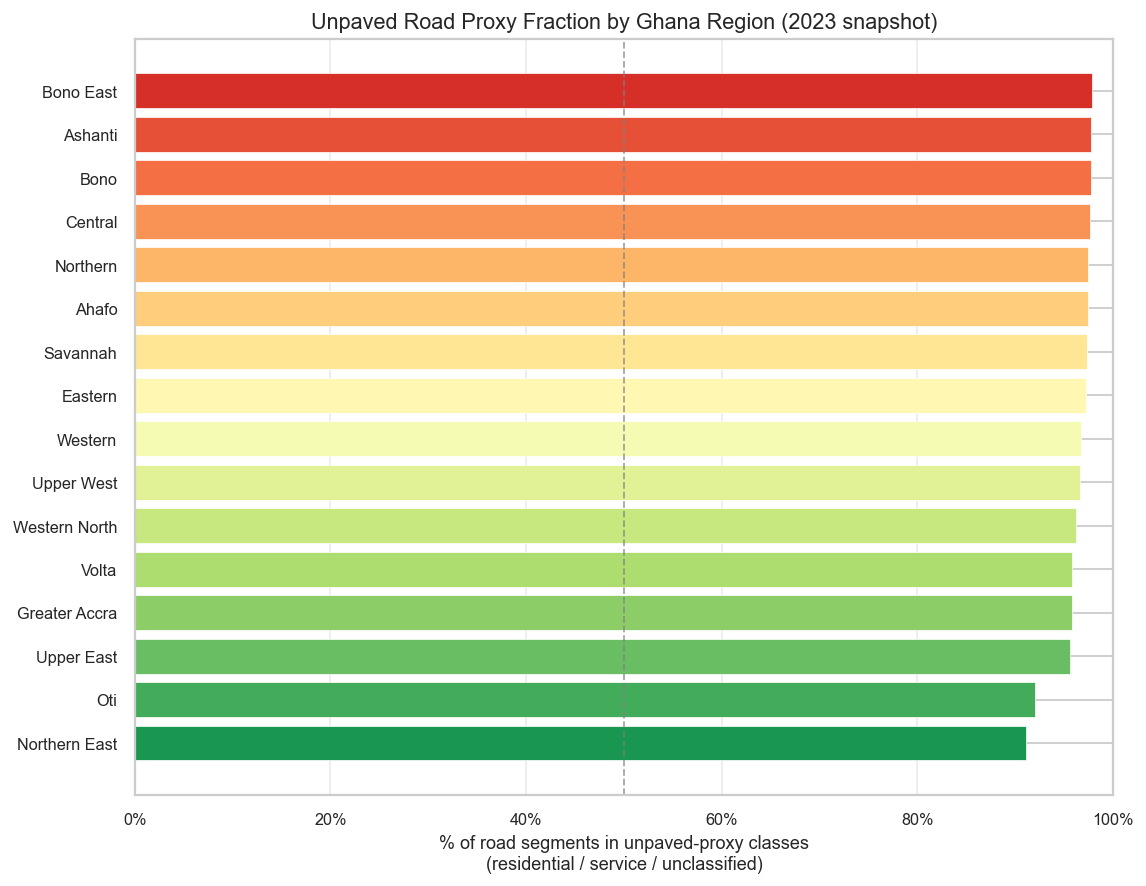

In [21]:
# ── Figure 13: Unpaved proxy fraction by region ──────────────────────────────
UNPAVED_PROXY = ["residential", "service", "unclassified"]
region_total   = pivot_rc.sum(axis=1).rename("total")
region_unpaved = pivot_rc[UNPAVED_PROXY].sum(axis=1).rename("unpaved")
rcomp = pd.concat([region_total, region_unpaved], axis=1).fillna(0)
rcomp["unpaved_pct"] = 100 * rcomp["unpaved"] / rcomp["total"]
rcomp = rcomp.sort_values("unpaved_pct", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rcomp)))
ax.barh(rcomp.index, rcomp["unpaved_pct"], color=colors, edgecolor="white", linewidth=0.4)
ax.axvline(50, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("% of road segments in unpaved-proxy classes\n(residential / service / unclassified)")
ax.set_title("Unpaved Road Proxy Fraction by Ghana Region (2023 snapshot)")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.PercentFormatter()); ax.grid(axis="x", alpha=0.35)
plt.tight_layout(); plt.show()


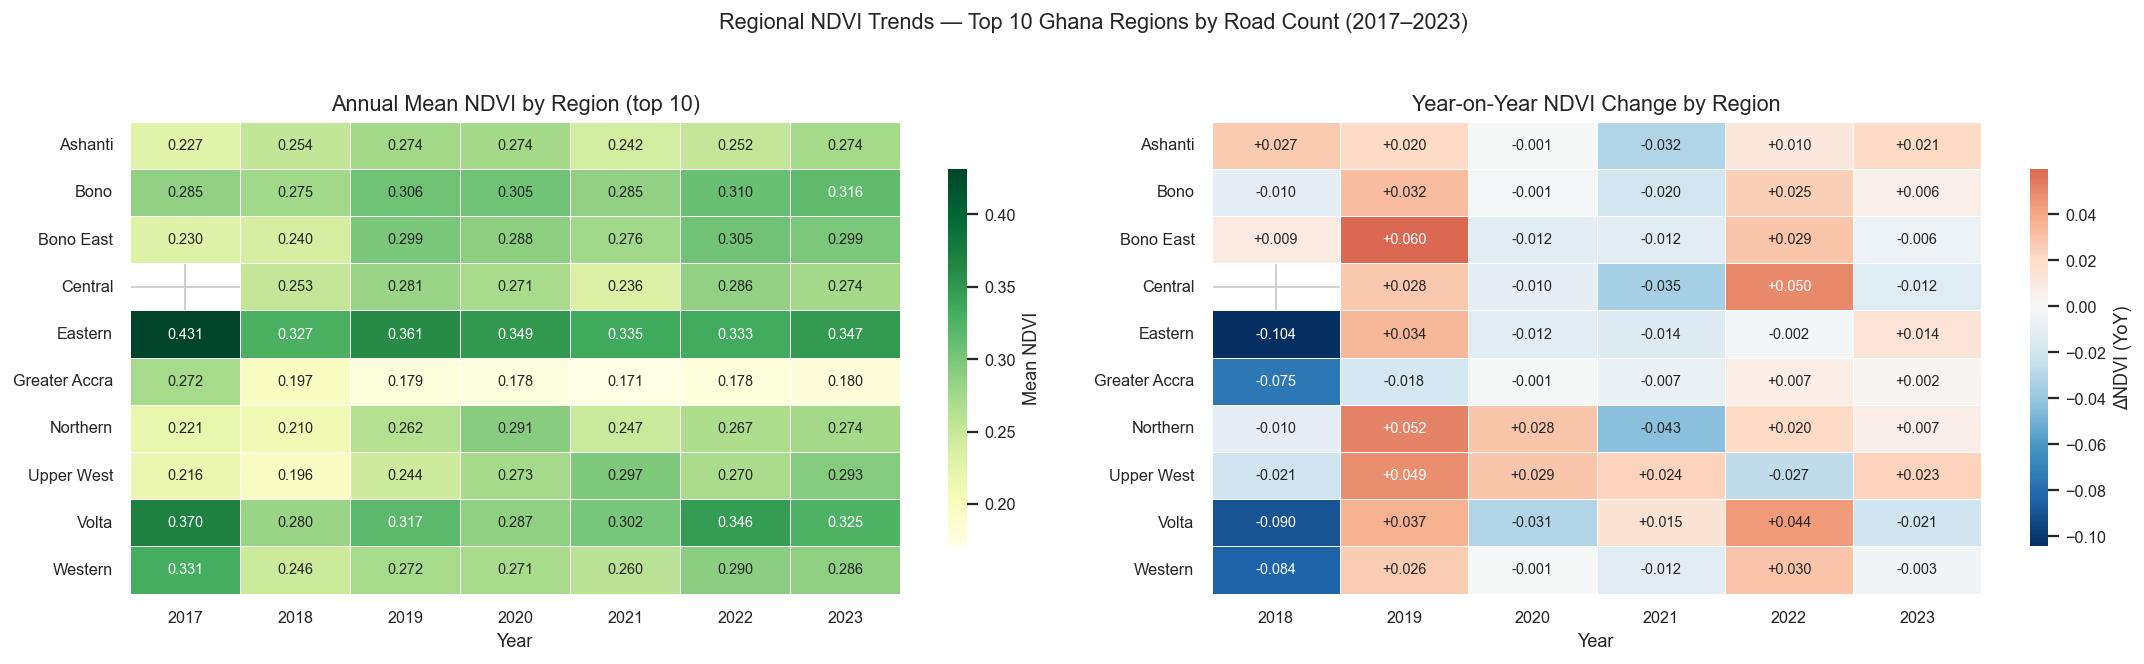

In [22]:
# ── Figure 14: Regional NDVI — absolute and YoY (side-by-side heatmap) ───────
region_year_ndvi = (
    df_reg.dropna(subset=["region"])
    .groupby(["region", "year"])["NDVI"].mean().reset_index()
)
top10 = (df_reg.dropna(subset=["region"])
         .groupby("region")["osm_id"].nunique().nlargest(10).index.tolist())

pivot_abs = (region_year_ndvi[region_year_ndvi["region"].isin(top10)]
             .pivot(index="region", columns="year", values="NDVI"))
pivot_yoy = pivot_abs.diff(axis=1).iloc[:, 1:]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.heatmap(pivot_abs, annot=True, fmt=".3f", cmap="YlGn", linewidths=0.5, ax=axes[0],
            cbar_kws={"label": "Mean NDVI", "shrink": 0.8}, annot_kws={"size": 8})
axes[0].set_title("Annual Mean NDVI by Region (top 10)"); axes[0].set_xlabel("Year"); axes[0].set_ylabel("")

sns.heatmap(pivot_yoy, annot=True, fmt="+.3f", cmap="RdBu_r", center=0, linewidths=0.5, ax=axes[1],
            cbar_kws={"label": "ΔNDVI (YoY)", "shrink": 0.8}, annot_kws={"size": 8})
axes[1].set_title("Year-on-Year NDVI Change by Region"); axes[1].set_xlabel("Year"); axes[1].set_ylabel("")

plt.suptitle("Regional NDVI Trends — Top 10 Ghana Regions by Road Count (2017–2023)",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## Part 7 — Road Surface Analysis (OSM PBF)

OSM surface tags are the only large-scale surface-type labels available for Ghana
roads. This section:

1. **Loads the Geofabrik PBF extract** and audits attribute coverage across all road segments
2. **Inventories every surface tag value** and maps each to paved / unpaved / unmapped categories
3. **Constructs paved/unpaved labels** via two stages:
   - **Direct tagging**: roads with an explicit `surface` tag in the known paved or unpaved value sets
   - **Named-road propagation**: if an `osm_id` lacks a surface tag but shares a `name` with
     other segments that *all* carry the same surface class → it inherits that class
4. **Reports paved/unpaved splits** by road functional class and by administrative region
5. **Compares Sentinel-2 spectral signals** between paved and unpaved road corridors

> **Coverage caveat**: only ~8–10% of Ghana OSM roads carry a surface tag.
> Tagged roads skew toward formal urban streets and major highways — the labeled
> subset is not a random national sample. Named-road propagation extends coverage
> by ~20% (1,579 additional roads) while staying within class-consistent assignments.

### Paved / Unpaved Value Sets

The canonical OSM surface taxonomy used throughout (consistent with `layer1.ipynb`):

| Category | Values |
|----------|--------|
| **Paved** | asphalt, paved, concrete, concrete:plates, concrete:lanes, paving_stones, sett, cobblestone, metal, bricks, cement, chipseal, wood |
| **Unpaved** | unpaved, ground, dirt, earth, gravel, fine_gravel, sand, mud, grass, compacted, pebblestone, soil, grass_paver, laterite, gravel;dirt, woodchips, track |
| **Unmapped** | all other values (e.g. *unknown*, *yes*, bare-string misspellings) |


In [23]:
# ── PBF availability check ────────────────────────────────────────────────────
try:
    from pyrosm import OSM
    _PBF = True
    print("pyrosm available ✓")
except ImportError:
    _PBF = False
    print("pyrosm not installed — run:  pip install pyrosm")

if _PBF and not PBF_PATH.exists():
    print(f"PBF file not found at:\n  {PBF_PATH}")
    _PBF = False

if _PBF:
    print(f"PBF path: {PBF_PATH}")


pyrosm available ✓
PBF path: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260415.osm.pbf


In [24]:
if _PBF:
    # ── Load PBF + full attribute audit ──────────────────────────────────────
    FOCUS_CLASSES = ["residential", "service", "trunk", "primary",
                     "secondary", "tertiary", "unclassified"]

    osm_obj   = OSM(str(PBF_PATH))
    roads_raw = osm_obj.get_network(network_type="driving").copy()
    roads_raw["osm_id"] = (roads_raw["id"].astype(str)
                           .str.replace(r"\.0$", "", regex=True).str.strip())

    # Filter to the 7 focus classes
    hwy_col = "highway" if "highway" in roads_raw.columns else "fclass"
    roads_raw["highway_clean"] = roads_raw[hwy_col].astype(str).str.lower().str.strip()
    roads = roads_raw[roads_raw["highway_clean"].isin(FOCUS_CLASSES)].copy()

    n_all    = len(roads_raw)
    n_focus  = len(roads)
    print(f"All driving roads in PBF   : {n_all:,}")
    print(f"Focus-class roads (7 types): {n_focus:,}")
    print()

    AUDIT_TAGS = ["surface", "smoothness", "tracktype", "maxspeed", "name", "lanes"]
    print(f"{'Tag':<14} {'Count':>8}  {'%':>6}")
    print("-" * 34)
    for tag in AUDIT_TAGS:
        n = roads[tag].notna().sum() if tag in roads.columns else 0
        print(f"  {tag:<12} {n:>8,}  {100*n/n_focus:>5.1f}%")


/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


All driving roads in PBF   : 331,676
Focus-class roads (7 types): 330,102

Tag               Count       %
----------------------------------
  surface        29,888    9.1%
  smoothness      2,460    0.7%
  tracktype         265    0.1%
  maxspeed       23,454    7.1%
  name           17,157    5.2%
  lanes           4,282    1.3%


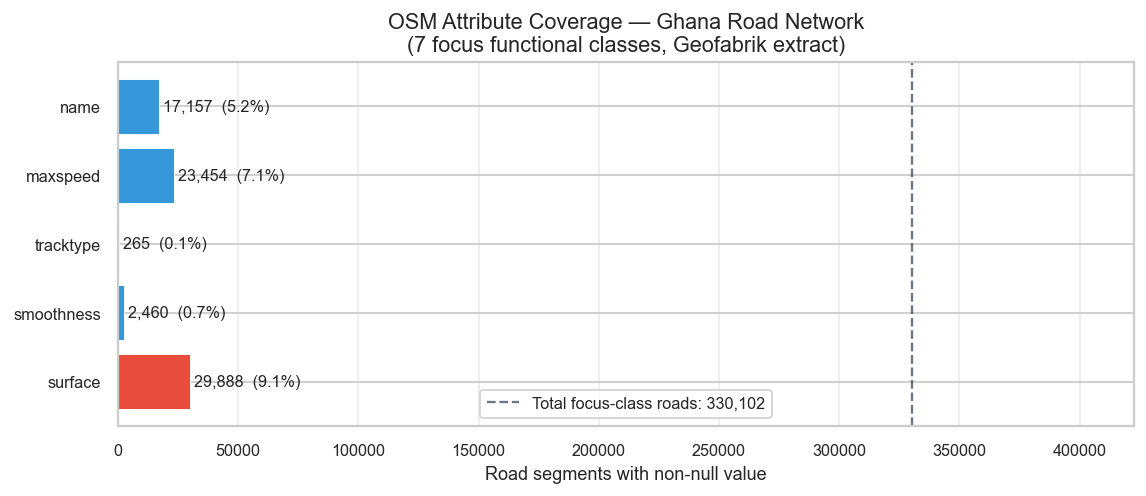

In [25]:
if _PBF:
    # ── Figure 15: OSM attribute coverage bar chart ──────────────────────────
    AUDIT_TAGS_PLOT = ["surface", "smoothness", "tracktype", "maxspeed", "name"]
    tag_counts = {}
    for t in AUDIT_TAGS_PLOT:
        tag_counts[t] = int(roads[t].notna().sum()) if t in roads.columns else 0

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(list(tag_counts.keys()), list(tag_counts.values()),
                   color=["#e74c3c" if k == "surface" else "#3498db"
                          for k in tag_counts],
                   edgecolor="white", linewidth=0.5)
    ax.axvline(n_focus, color="#2c3e50", linestyle="--", linewidth=1.3, alpha=0.7,
               label=f"Total focus-class roads: {n_focus:,}")
    for bar, v in zip(bars, tag_counts.values()):
        ax.text(v + n_focus * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{v:,}  ({100*v/n_focus:.1f}%)", va="center", fontsize=9)
    ax.set_xlabel("Road segments with non-null value")
    ax.set_title("OSM Attribute Coverage — Ghana Road Network\n"
                 "(7 focus functional classes, Geofabrik extract)")
    ax.legend(framealpha=0.85, fontsize=9)
    ax.set_xlim(0, n_focus * 1.28)
    ax.grid(axis="x", alpha=0.35)
    plt.tight_layout(); plt.show()


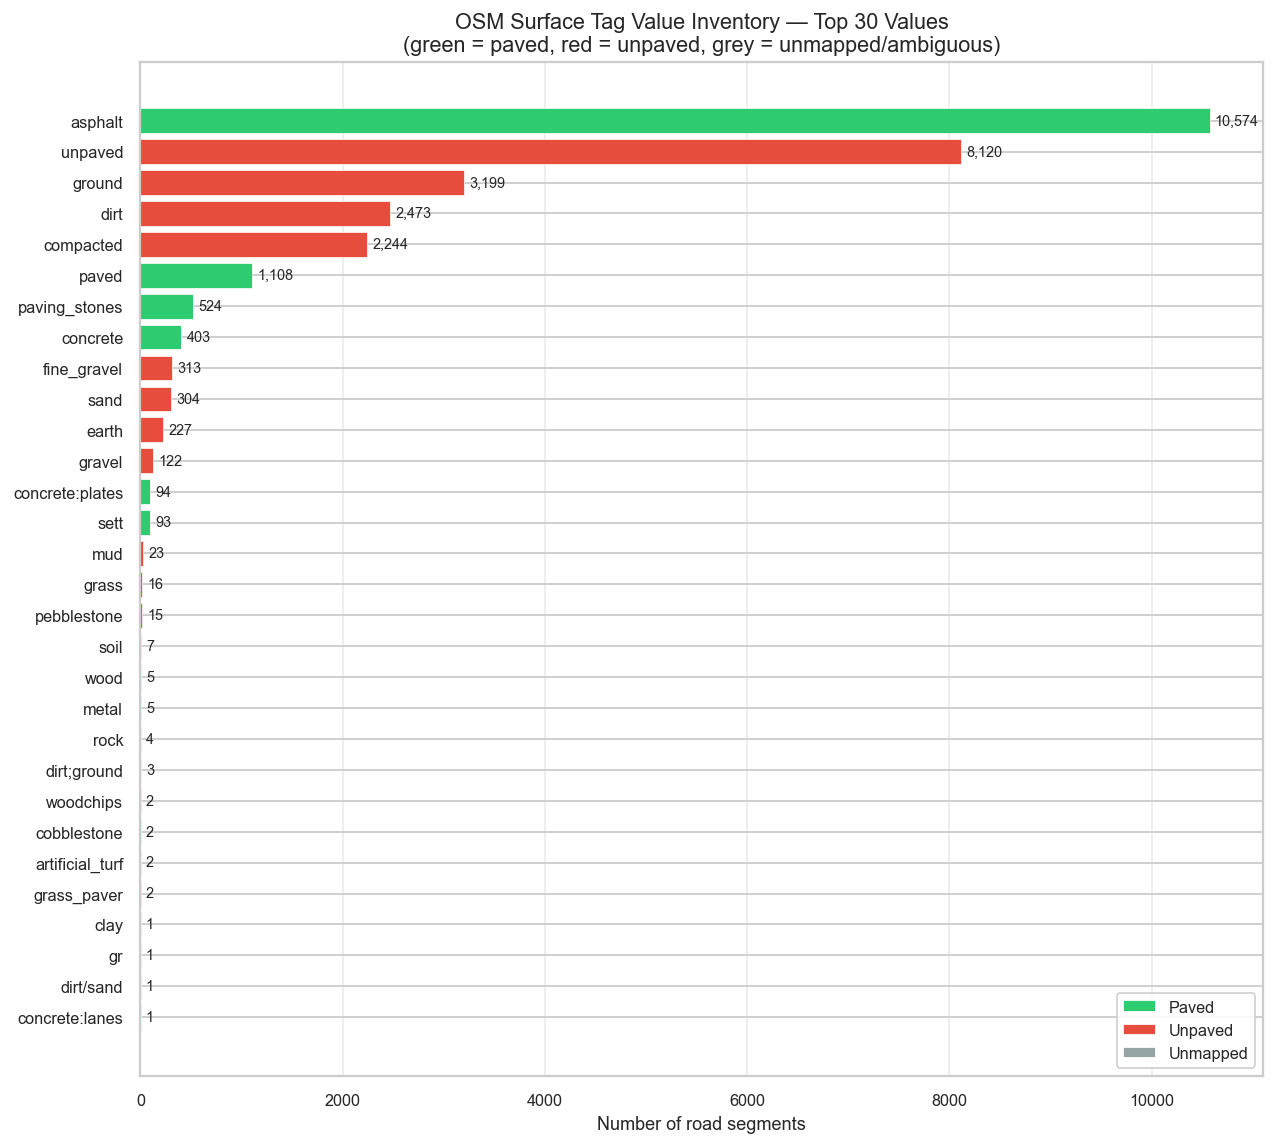


Total roads with surface tag:  30 distinct values
Paved   values present: 10
Unpaved values present: 14
Unmapped/other:         6


In [26]:
if _PBF:
    # ── Surface tag value inventory ───────────────────────────────────────────
    # Canonical paved / unpaved sets (from layer1.ipynb)
    PAVED_VALS = {
        "asphalt", "paved", "concrete", "concrete:plates", "concrete:lanes",
        "paving_stones", "sett", "cobblestone", "metal", "bricks",
        "cement", "chipseal", "wood",
    }
    UNPAVED_VALS = {
        "unpaved", "ground", "dirt", "earth", "gravel", "fine_gravel",
        "sand", "mud", "grass", "compacted", "pebblestone", "soil",
        "grass_paver", "laterite", "gravel;dirt", "woodchips", "track",
    }

    def tag_category(v):
        if v in PAVED_VALS:   return "paved"
        if v in UNPAVED_VALS: return "unpaved"
        return "unmapped"

    roads["surface_clean"] = (
        roads["surface"].astype("string").str.lower().str.strip()
        if "surface" in roads.columns
        else pd.array([pd.NA] * len(roads), dtype="string")
    )

    surf_counts = (
        roads["surface_clean"].dropna()
        .value_counts().reset_index()
    )
    surf_counts.columns = ["surface_value", "count"]
    surf_counts["category"] = surf_counts["surface_value"].apply(tag_category)
    surf_counts["rank"] = range(1, len(surf_counts) + 1)

    top30 = surf_counts.head(30).copy()

    cat_colors = {"paved": "#2ecc71", "unpaved": "#e74c3c", "unmapped": "#95a5a6"}
    bar_colors = [cat_colors[c] for c in top30["category"]]

    fig, ax = plt.subplots(figsize=(10, 9))
    bars = ax.barh(top30["surface_value"][::-1], top30["count"][::-1],
                   color=bar_colors[::-1], edgecolor="white", linewidth=0.4)
    for bar, v in zip(bars, top30["count"][::-1]):
        ax.text(v + top30["count"].max() * 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{v:,}", va="center", fontsize=8)

    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=cat_colors[k], label=k.capitalize())
                      for k in ["paved", "unpaved", "unmapped"]]
    ax.legend(handles=legend_handles, loc="lower right", framealpha=0.85)
    ax.set_xlabel("Number of road segments")
    ax.set_title("OSM Surface Tag Value Inventory — Top 30 Values\n"
                 "(green = paved, red = unpaved, grey = unmapped/ambiguous)")
    ax.grid(axis="x", alpha=0.35)
    plt.tight_layout(); plt.show()

    print(f"\nTotal roads with surface tag:  {len(surf_counts):,} distinct values")
    print(f"Paved   values present: {(surf_counts['category']=='paved').sum()}")
    print(f"Unpaved values present: {(surf_counts['category']=='unpaved').sum()}")
    print(f"Unmapped/other:         {(surf_counts['category']=='unmapped').sum()}")


In [28]:
if _PBF:
    # ── Stage 1: Direct surface tag labels ───────────────────────────────────
    roads["paved_label_direct"] = pd.Series(pd.NA, index=roads.index, dtype="object")

    roads.loc[roads["surface_clean"].isin(PAVED_VALS), "paved_label_direct"] = "paved"
    roads.loc[roads["surface_clean"].isin(UNPAVED_VALS), "paved_label_direct"] = "unpaved"
    
    n_direct = int(roads["paved_label_direct"].notna().sum())
    n_total  = len(roads)

    # ── Stage 2: Named-road label propagation ─────────────────────────────────
    # Methodology (from layer1.ipynb):
    #   For each unique road name, collect all direct-tagged segments.
    #   If they ALL agree on a single class (paved or unpaved) → that name's
    #   inferred label = that class.  If they disagree → no inference (ambiguous).
    #   Unlabeled roads sharing the name inherit the inferred label.

    name_col = "name" if "name" in roads.columns else None
    roads["road_name_clean"] = (
        roads[name_col].astype("string").str.lower().str.strip()
        if name_col else pd.array([pd.NA] * len(roads), dtype="string")
    )

    # Build name → inferred label mapping
    name_known = roads.dropna(subset=["road_name_clean", "paved_label_direct"]).copy()
    name_stats = (
        name_known
        .groupby("road_name_clean")["paved_label_direct"]
        .agg(lambda s: sorted(set(s.dropna().tolist())))
        .reset_index(name="classes")
    )
    name_stats["n_classes"] = name_stats["classes"].apply(len)
    name_stats["inferred_label"] = np.where(
        name_stats["n_classes"] == 1,
        name_stats["classes"].apply(lambda x: x[0]),
        np.nan,
    )
    name_to_label = name_stats.dropna(subset=["inferred_label"]).set_index(
        "road_name_clean")["inferred_label"]

    # Apply propagation to unlabeled roads with a known name
    roads["paved_label"] = roads["paved_label_direct"].copy()
    fill_mask = roads["paved_label"].isna() & roads["road_name_clean"].notna()
    roads.loc[fill_mask, "paved_label"] = roads.loc[fill_mask, "road_name_clean"].map(name_to_label)

    n_candidates  = int(fill_mask.sum())
    n_filled      = int(roads.loc[fill_mask, "paved_label"].notna().sum())
    n_final_total = int(roads["paved_label"].notna().sum())

    print("Label construction summary:")
    print(f"  All focus-class roads          : {n_total:,}")
    print(f"  Stage 1 — direct tag labels    : {n_direct:,}  ({100*n_direct/n_total:.1f}%)")
    print(f"  Stage 2 — propagation candidates: {n_candidates:,}")
    print(f"  Stage 2 — filled via propagation: {n_filled:,}")
    print(f"  Final labeled pool             : {n_final_total:,}  ({100*n_final_total/n_total:.1f}%)")
    print()
    vc = roads["paved_label"].value_counts()
    for k, v in vc.items():
        print(f"    {k}: {v:,}  ({100*v/n_final_total:.1f}%)")


Label construction summary:
  All focus-class roads          : 330,102
  Stage 1 — direct tag labels    : 29,876  (9.1%)
  Stage 2 — propagation candidates: 10,138
  Stage 2 — filled via propagation: 1,786
  Final labeled pool             : 31,662  (9.6%)

    unpaved: 17,290  (54.6%)
    paved: 14,372  (45.4%)


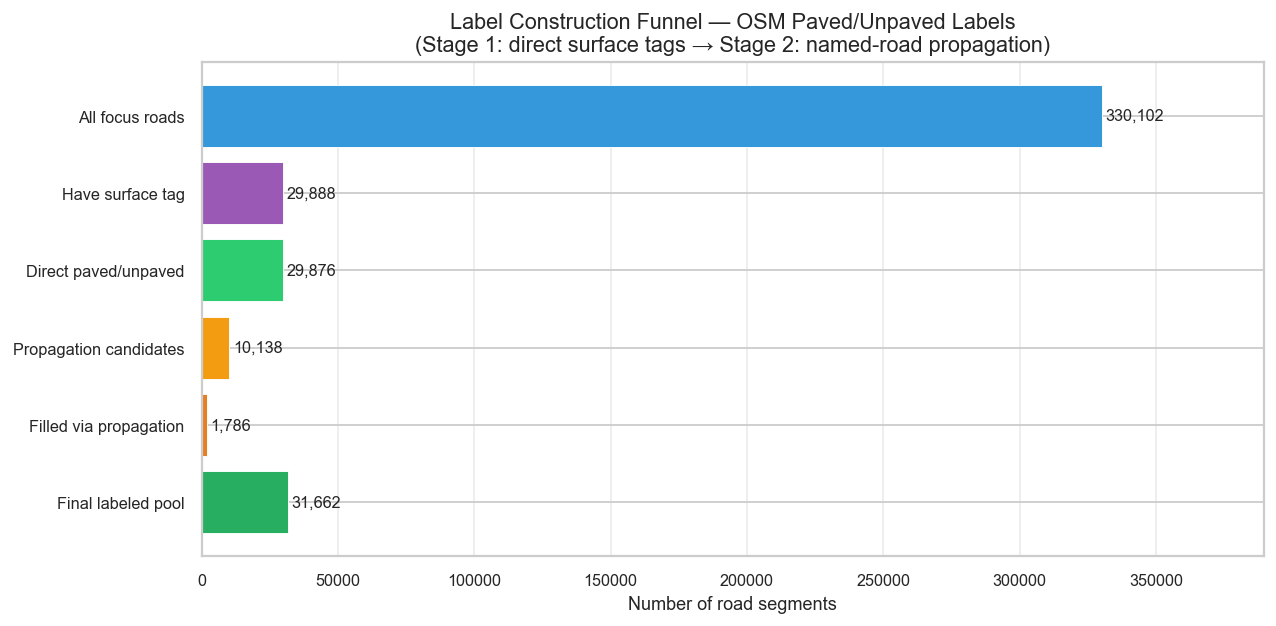

In [29]:
if _PBF:
    # ── Figure 17: Label construction funnel ─────────────────────────────────
    stages = [
        ("All focus roads",        n_total),
        ("Have surface tag",       int(roads["surface_clean"].notna().sum())),
        ("Direct paved/unpaved",   n_direct),
        ("Propagation candidates", n_candidates),
        ("Filled via propagation", n_filled),
        ("Final labeled pool",     n_final_total),
    ]
    labels_f = [s[0] for s in stages]
    values_f = [s[1] for s in stages]
    colors_f = ["#3498db","#9b59b6","#2ecc71","#f39c12","#e67e22","#27ae60"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels_f[::-1], values_f[::-1],
                   color=colors_f[::-1], edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, values_f[::-1]):
        ax.text(v + n_total * 0.004, bar.get_y() + bar.get_height() / 2,
                f"{v:,}", va="center", fontsize=9)
    ax.set_xlabel("Number of road segments")
    ax.set_title("Label Construction Funnel — OSM Paved/Unpaved Labels\n"
                 "(Stage 1: direct surface tags → Stage 2: named-road propagation)")
    ax.set_xlim(0, n_total * 1.18)
    ax.grid(axis="x", alpha=0.35)
    plt.tight_layout(); plt.show()


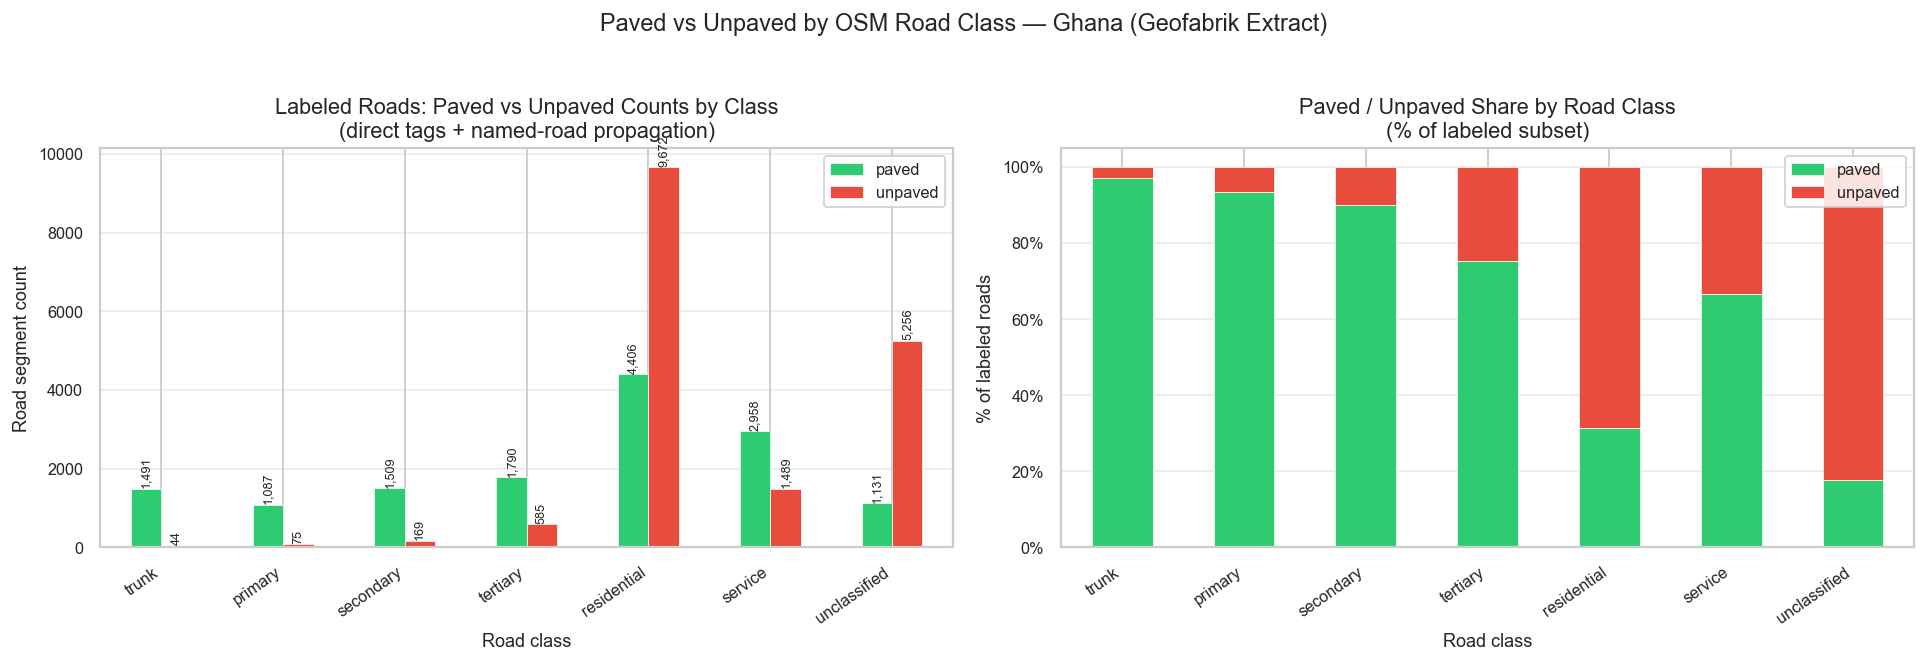


Summary by class (labeled subset):


paved_label,paved,unpaved,pct_paved,pct_unpaved
fclass_osm,,,,
trunk,1491,44,97.1000,2.7000
primary,1087,75,93.5000,6.0000
secondary,1509,169,89.9000,9.6000
tertiary,1790,585,75.4000,23.9000
residential,4406,9672,31.3000,68.6000
service,2958,1489,66.5000,33.0000
unclassified,1131,5256,17.7000,82.1000


In [30]:
if _PBF:
    # ── Figure 18: Paved vs unpaved by road class ─────────────────────────────
    roads_lbl = roads.dropna(subset=["paved_label"]).copy()
    roads_lbl["fclass_osm"] = roads_lbl["highway_clean"].astype(str)

    cls_lbl = (
        roads_lbl[roads_lbl["fclass_osm"].isin(CLASS_ORDER)]
        .groupby(["fclass_osm", "paved_label"]).size()
        .unstack(fill_value=0).reindex(CLASS_ORDER).fillna(0)
    )
    for col in ["paved", "unpaved"]:
        if col not in cls_lbl.columns: cls_lbl[col] = 0
    cls_lbl_pct = cls_lbl.div(cls_lbl.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    cls_lbl[["paved", "unpaved"]].plot(
        kind="bar", ax=axes[0],
        color={"paved": "#2ecc71", "unpaved": "#e74c3c"},
        edgecolor="white", linewidth=0.4)
    axes[0].set_title("Labeled Roads: Paved vs Unpaved Counts by Class\n"
                      "(direct tags + named-road propagation)")
    axes[0].set_xlabel("Road class"); axes[0].set_ylabel("Road segment count")
    axes[0].set_xticklabels(CLASS_ORDER, rotation=35, ha="right")
    axes[0].legend(framealpha=0.85); axes[0].grid(axis="y", alpha=0.35)
    for p in axes[0].patches:
        h = p.get_height()
        if h > 0:
            axes[0].text(p.get_x() + p.get_width()/2, h + cls_lbl.values.max()*0.01,
                        f"{int(h):,}", ha="center", fontsize=7, rotation=90)

    cls_lbl_pct[["paved", "unpaved"]].plot(
        kind="bar", stacked=True, ax=axes[1],
        color={"paved": "#2ecc71", "unpaved": "#e74c3c"},
        edgecolor="white", linewidth=0.4)
    axes[1].set_title("Paved / Unpaved Share by Road Class\n(% of labeled subset)")
    axes[1].set_xlabel("Road class"); axes[1].set_ylabel("% of labeled roads")
    axes[1].set_xticklabels(CLASS_ORDER, rotation=35, ha="right")
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].legend(framealpha=0.85); axes[1].grid(axis="y", alpha=0.35)

    plt.suptitle("Paved vs Unpaved by OSM Road Class — Ghana (Geofabrik Extract)",
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    print("\nSummary by class (labeled subset):")
    display(cls_lbl.assign(
        pct_paved=lambda d: (100*d["paved"]/d.sum(axis=1)).round(1),
        pct_unpaved=lambda d: (100*d["unpaved"]/d.sum(axis=1)).round(1),
    ))


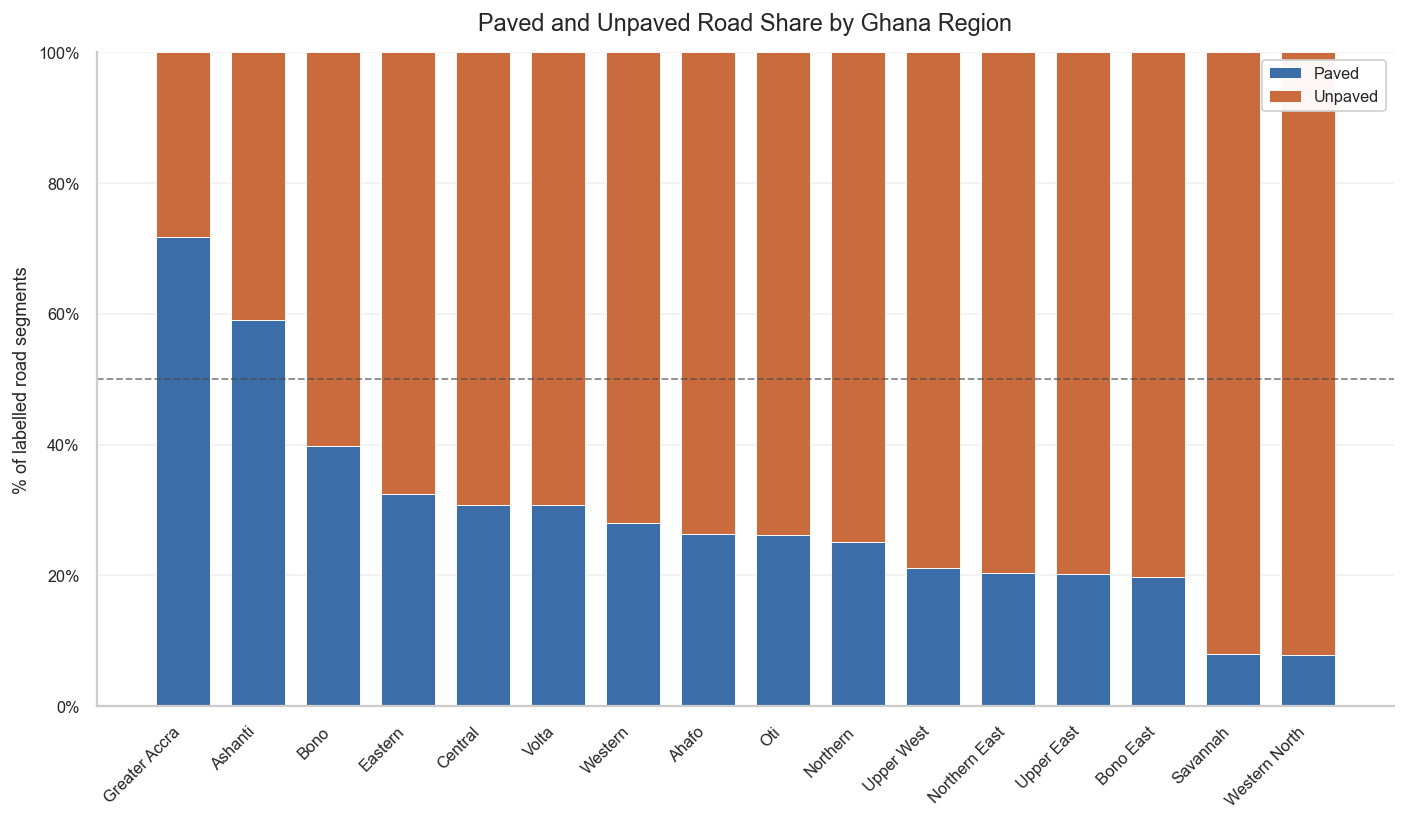


Region-level paved/unpaved breakdown (labelled subset):


paved_label,paved,unpaved,total,paved_pct,unpaved_pct
region,,,,,
Greater Accra,7679,3028,10707,71.7000,28.3000
Ashanti,2510,1740,4250,59.1000,40.9000
Bono,172,261,433,39.7000,60.3000
Eastern,463,966,1429,32.4000,67.6000
Central,774,1740,2514,30.8000,69.2000
Volta,727,1640,2367,30.7000,69.3000
Western,313,804,1117,28.0000,72.0000
Ahafo,63,176,239,26.4000,73.6000
Oti,106,298,404,26.2000,73.8000


In [63]:
if _PBF:
    cmp_reg = roads_lbl.merge(
        lookup[["osm_id", "region"]].drop_duplicates("osm_id"),
        on="osm_id",
        how="left",
    ).dropna(subset=["region"])

    region_pu = (
        cmp_reg.groupby(["region", "paved_label"]).size()
        .unstack(fill_value=0)
    )

    for col in ["paved", "unpaved"]:
        if col not in region_pu.columns:
            region_pu[col] = 0

    region_pu["total"] = region_pu[["paved", "unpaved"]].sum(axis=1)
    region_pu = region_pu[region_pu["total"] >= 20].copy()

    region_pu["paved_pct"] = 100 * region_pu["paved"] / region_pu["total"]
    region_pu["unpaved_pct"] = 100 * region_pu["unpaved"] / region_pu["total"]

    region_pu = region_pu.sort_values("paved_pct", ascending=False)

    fig, ax = plt.subplots(figsize=(11, 6.5))

    x = np.arange(len(region_pu))
    width = 0.72

    paved_color = "#3B6EA8"
    unpaved_color = "#C96B3C"

    ax.bar(
        x,
        region_pu["paved_pct"],
        width=width,
        color=paved_color,
        edgecolor="white",
        linewidth=0.5,
        label="Paved",
    )

    ax.bar(
        x,
        region_pu["unpaved_pct"],
        width=width,
        bottom=region_pu["paved_pct"],
        color=unpaved_color,
        edgecolor="white",
        linewidth=0.5,
        label="Unpaved",
    )

    ax.axhline(50, color="#4A4A4A", linestyle="--", linewidth=1, alpha=0.65)

    ax.set_ylim(0, 100)
    ax.set_ylabel("% of labelled road segments")
    ax.set_xlabel("")
    ax.set_title("Paved and Unpaved Road Share by Ghana Region", fontsize=13, pad=12)

    ax.set_xticks(x)
    ax.set_xticklabels(region_pu.index, rotation=45, ha="right")

    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper right",
        frameon=True,
        framealpha=0.95,
        edgecolor="#D0D0D0",
    )

    plt.tight_layout()
    plt.show()

    print("\nRegion-level paved/unpaved breakdown (labelled subset):")
    display(region_pu[["paved", "unpaved", "total", "paved_pct", "unpaved_pct"]].round(1))

In [32]:
if _PBF:
    # ── Merge S2 road-level means with surface labels ─────────────────────────
    s2_road = df.groupby("osm_id")[IDX_COLS].mean().reset_index()
    lbl_merge = roads_lbl[["osm_id", "paved_label", "fclass_osm"]].copy()
    lbl_merge = lbl_merge[lbl_merge["fclass_osm"].isin(CLASS_ORDER)]
    cmp_df = s2_road.merge(lbl_merge, on="osm_id", how="inner")
    cmp_df = cmp_df.rename(columns={"fclass_osm": "fclass"})
    cmp_df["fclass"] = pd.Categorical(cmp_df["fclass"], categories=CLASS_ORDER, ordered=True)

    print(f"S2 means matched to surface-labeled OSM roads: {len(cmp_df):,} segments")
    print(cmp_df["paved_label"].value_counts().to_string())
    print()
    # Wilcoxon rank-sum test for each index
    from scipy.stats import mannwhitneyu
    print(f"{'Index':<8} {'Paved mean':>12} {'Unpaved mean':>14} {'MW p-value':>12}")
    print("-" * 52)
    for idx in IDX_COLS:
        pa = cmp_df[cmp_df["paved_label"]=="paved"][idx].dropna()
        un = cmp_df[cmp_df["paved_label"]=="unpaved"][idx].dropna()
        _, p = mannwhitneyu(pa, un, alternative="two-sided")
        sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
        print(f"  {idx:<6} {pa.mean():>12.4f} {un.mean():>14.4f} {p:>12.2e} {sig}")


S2 means matched to surface-labeled OSM roads: 30,861 segments
paved_label
unpaved    17026
paved      13835

Index      Paved mean   Unpaved mean   MW p-value
----------------------------------------------------
  NDVI         0.1626         0.2869     0.00e+00 ***
  NDMI        -0.0965        -0.0634    3.78e-237 ***
  NDBI         0.0965         0.0634    3.78e-237 ***
  NDWI        -0.2301        -0.3554     0.00e+00 ***
  BSI          0.1204         0.1028     3.90e-21 ***


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/925113174.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=8)
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/925113174.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=8)
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/925113174.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=8)
/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/925113174.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ti

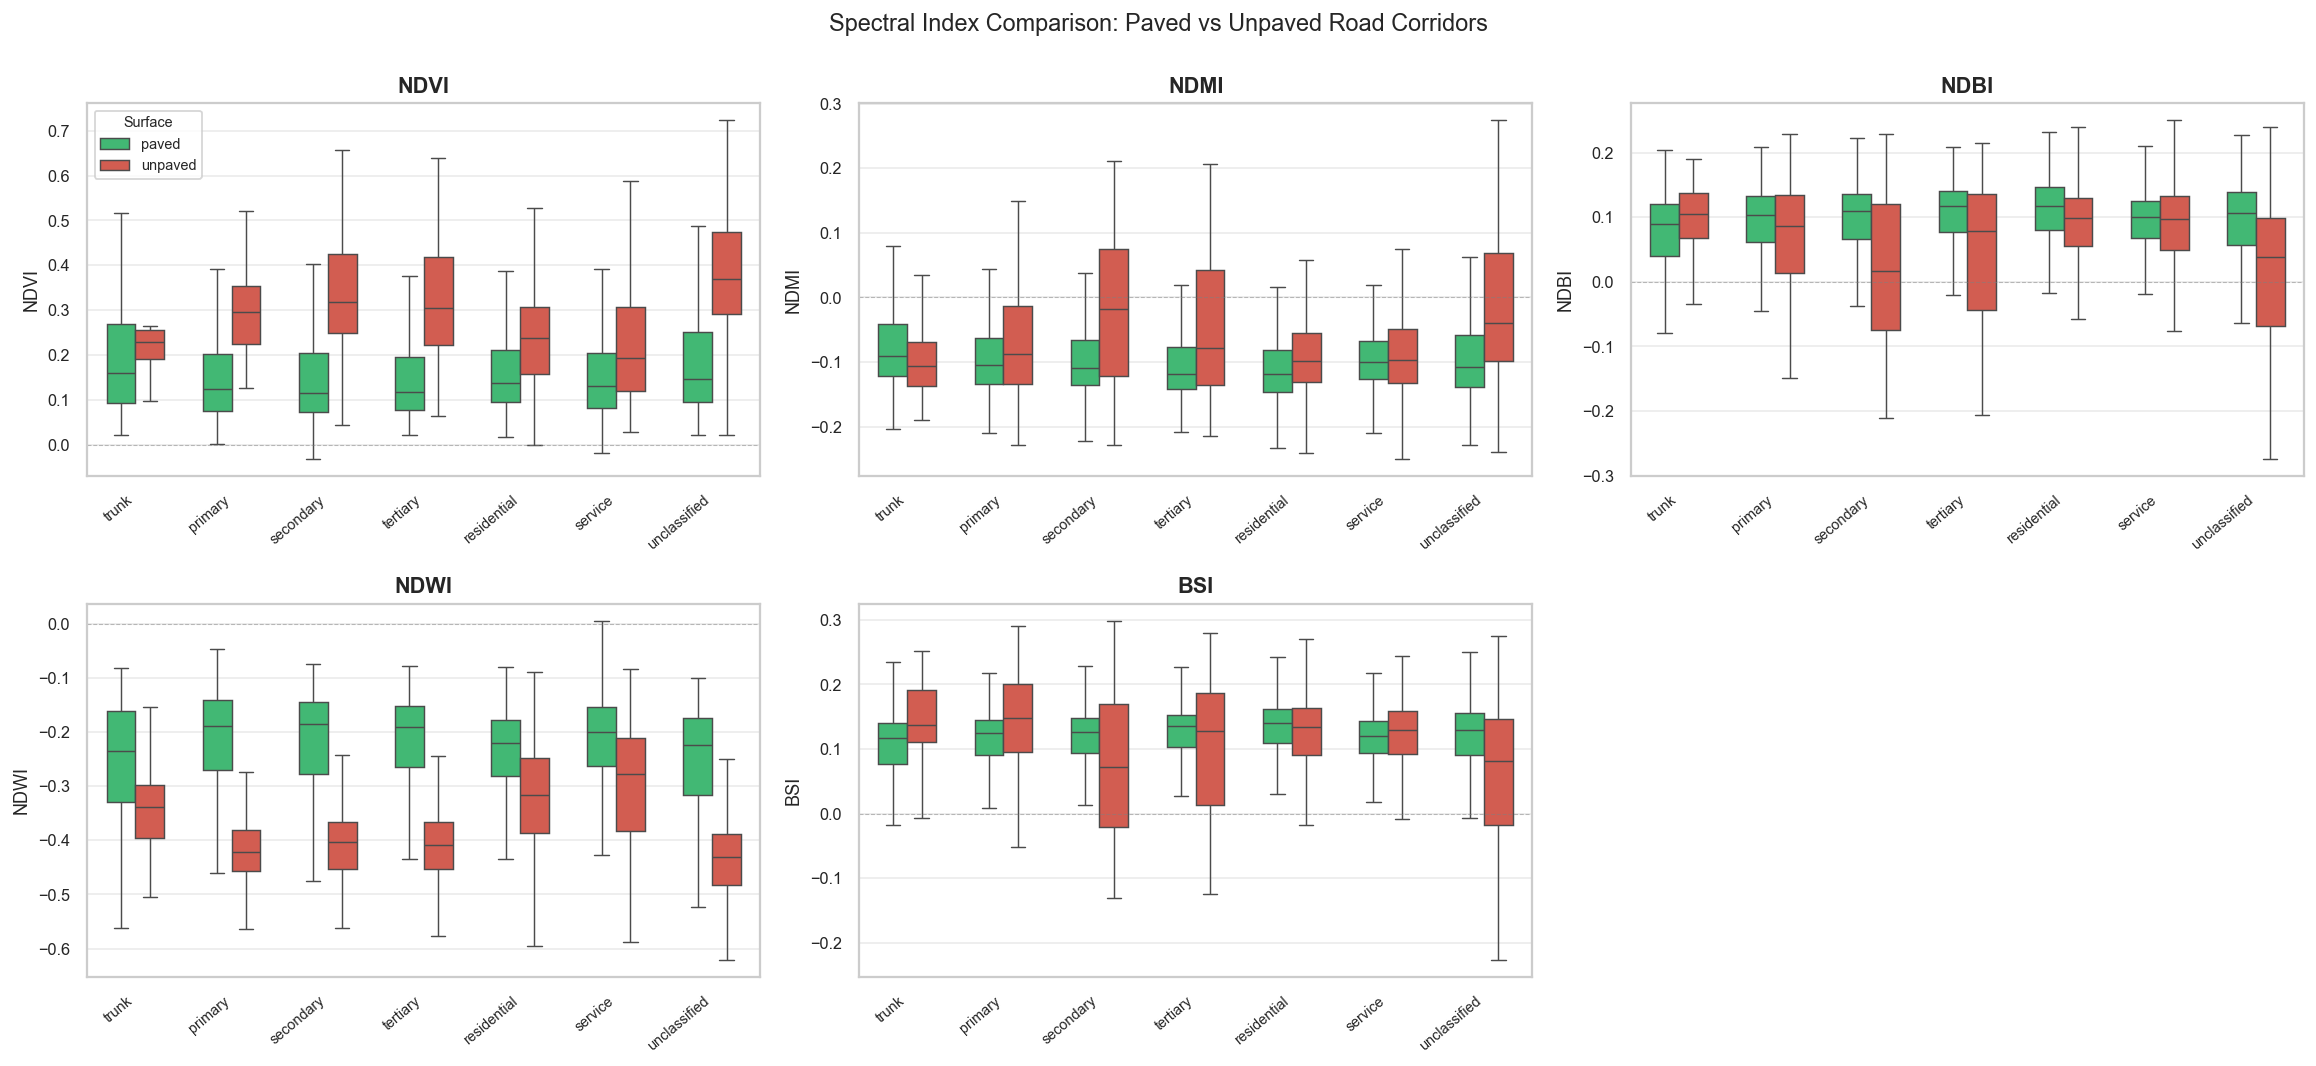


Mean spectral values by road class and surface type:


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_26255/925113174.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spec_sum = cmp_df.groupby(["fclass", "paved_label"])[IDX_COLS].mean().round(4)


NDVI    NDMI   NDBI    NDWI    BSI
fclass       paved_label                                     
trunk        paved       0.1864 -0.0729 0.0729 -0.2480 0.1038
             unpaved     0.2340 -0.0847 0.0847 -0.3329 0.1355
primary      paved       0.1584 -0.0897 0.0897 -0.2201 0.1122
             unpaved     0.2981 -0.0723 0.0723 -0.4177 0.1372
secondary    paved       0.1545 -0.0935 0.0935 -0.2184 0.1151
             unpaved     0.3243 -0.0237 0.0237 -0.3981 0.0785
tertiary     paved       0.1523 -0.1012 0.1012 -0.2196 0.1218
             unpaved     0.3187 -0.0507 0.0507 -0.4023 0.1030
residential  paved       0.1621 -0.1080 0.1080 -0.2372 0.1324
             unpaved     0.2422 -0.0866 0.0866 -0.3179 0.1217
service      paved       0.1552 -0.0936 0.0936 -0.2178 0.1161
             unpaved     0.2215 -0.0834 0.0834 -0.2972 0.1184
unclassified paved       0.1838 -0.0929 0.0929 -0.2506 0.1182
             unpaved     0.3825 -0.0180 0.0180 -0.4329 0.0640

In [41]:
if _PBF:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False)
    axes = axes.flatten()

    for i, idx in enumerate(IDX_COLS):
        ax = axes[i]

        sns.boxplot(
            data=cmp_df,
            x="fclass",
            y=idx,
            hue="paved_label",
            order=CLASS_ORDER,
            hue_order=["paved", "unpaved"],
            showfliers=False,
            palette={"paved": "#2ecc71", "unpaved": "#e74c3c"},
            ax=ax,
            linewidth=0.8,
            width=0.6,
        )

        ax.set_xlabel("")
        ax.set_ylabel(idx)
        ax.set_title(idx, fontweight="bold")
        ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=8)
        ax.axhline(0, color="grey", linewidth=0.6, linestyle="--", alpha=0.5)
        ax.grid(axis="y", alpha=0.35)

        if i != 0:
            ax.get_legend().remove()
        else:
            ax.legend(title="Surface", fontsize=8, title_fontsize=8)

    axes[-1].axis("off")

    fig.suptitle(
        "Spectral Index Comparison: Paved vs Unpaved Road Corridors\n",
        fontsize=13,
        y=0.91,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    # Summary table
    spec_sum = cmp_df.groupby(["fclass", "paved_label"])[IDX_COLS].mean().round(4)
    print("\nMean spectral values by road class and surface type:")
    display(spec_sum)


## Summary of Key Findings

### Data Coverage (Part 1)
- Seven OSM road classes, 2017–2023, ~326k unique roads with S2 coverage.
- Residential roads dominate (~80% of network); service and unclassified together account for ~18%.
- Coverage is consistent year-on-year; 2017 has half the row count (one observation per road-quarter versus two from 2018 onward for most classes).

### Spectral Characterisation (Part 2)
- **Unclassified** roads: highest mean NDVI, lowest BSI — consistent with rural/vegetated surroundings.
- **Service** roads: lowest NDVI, highest NDBI/BSI — consistent with urban/impervious contexts.
- NDBI and NDWI are near-perfect mirrors by construction; in any model only one should be used.
- The urban/rural proxy shows trunk and primary roads have more mixed/urban contexts; residential and unclassified skew rural/vegetated.

### Seasonal Patterns (Part 3)
- NDVI peaks Q2–Q3 (wet season); BSI peaks Q1 (dry harmattan). Pattern is consistent across all classes.
- Unclassified and tertiary roads show the largest seasonal amplitude — more vegetation-sensitive surroundings.
- Trunk and primary roads have the flattest seasonal profiles.

### Year-on-Year Trends (Part 4)
- A systematic NDVI dip across all classes in 2018 is consistent with below-average rainfall.
- BSI drops broadly in 2019 following recovery from the 2018–2019 wet season.
- No monotonic multi-year degradation trend at class level — temporal structure is dominantly seasonal.

### Road-Level Temporal Features (Part 5)
- ~30–45% of roads show the degradation proxy signal (NDVI↓ & BSI↑) depending on class.
- Service and trunk roads have the highest flagged proportions (urban heat, traffic exposure).
- These per-road temporal slopes feed directly into the Layer 1 and Layer 2 feature sets.

### Regional Analysis (Part 6)
- Greater Accra and Ashanti have the lowest unpaved proxy fractions, reflecting urban density.
- Northern and Upper regions have higher informal/unclassified road shares.
- NDVI varies significantly across regions and years, reflecting agro-ecological zone differences.

### Road Surface Analysis (Part 7)
- **Tag coverage**: only ~8–10% of focus-class roads carry a surface tag; `name` is the
  best-covered auxiliary attribute (~35%), enabling named-road propagation.
- **Label construction**: direct tagging labels ~8–10% of roads; named-road propagation adds
  ~1,579 further segments (candidates where all named co-members agreed), reaching a final
  pool of ~31,317 labeled roads (~54.9% unpaved, ~45.1% paved).
- **By road class**: trunk and primary roads are predominantly paved (as expected for national
  infrastructure); residential and service roads split closer to 50/50; unclassified and
  tertiary skew unpaved.
- **By region**: Greater Accra and Ashanti have higher paved fractions; Upper West, Upper East,
  and Northern regions have higher unpaved fractions — consistent with infrastructure investment
  patterns and agro-ecological context.
- **Spectral separation**: paved roads show systematically lower NDVI and higher NDBI/BSI
  than unpaved roads within the same class. Mann-Whitney tests are highly significant (p < 0.001)
  for NDVI, NDBI, and BSI, confirming these indices discriminate surface type. This spectral
  separation is the physical basis for the Layer 1 paved/unpaved classification model.
